**IMPORT LIBRARIES AND SETUP**

In [4]:
# ENDO-TWIN - Section 1
# Import Libraries
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
# Reproducibility
np.random.seed(42)
print("Libraries imported successfully.")

# Upload datasets
# ============================================
from google.colab import files
uploaded = files.upload()
print("Files uploaded:")
for filename in uploaded.keys():
    print("-", filename)

Libraries imported successfully.


Saving ENDO_TWIN_synthetic_dataset.csv to ENDO_TWIN_synthetic_dataset.csv
Saving wrist_temperature.csv-2.download.zip to wrist_temperature.csv-2.download.zip
Saving wrist_temperature.csv.download.zip to wrist_temperature.csv.download.zip
Saving sleep_score.csv to sleep_score.csv
Saving heart_rate_variability_details.csv.download.zip to heart_rate_variability_details.csv.download.zip
Saving resting_heart_rate.csv to resting_heart_rate.csv
Saving hormones_and_selfreport.csv to hormones_and_selfreport.csv
Saving subject-info.csv to subject-info.csv
Files uploaded:
- ENDO_TWIN_synthetic_dataset.csv
- wrist_temperature.csv-2.download.zip
- wrist_temperature.csv.download.zip
- sleep_score.csv
- heart_rate_variability_details.csv.download.zip
- resting_heart_rate.csv
- hormones_and_selfreport.csv
- subject-info.csv


In [5]:
# Load real datasets
# ============================================
subject_info = pd.read_csv("subject-info.csv")
hormones = pd.read_csv("hormones_and_selfreport.csv")
resting_hr = pd.read_csv("resting_heart_rate.csv")
sleep_score = pd.read_csv("sleep_score.csv")
print("Basic datasets loaded successfully.")

# Extract ZIP files
# ============================================
import zipfile
import os
# Extract HRV
with zipfile.ZipFile(
    "heart_rate_variability_details.csv.download.zip",
    "r"
) as zip_ref:
    zip_ref.extractall("hrv_data")

# Extract temperature
with zipfile.ZipFile(
    "wrist_temperature.csv.download.zip",
    "r"
) as zip_ref:
    zip_ref.extractall("temperature_data")
print("ZIP files extracted successfully.")

# Find extracted CSV files
for root, dirs, files_list in os.walk("."):
    for file in files_list:
        if file.endswith(".csv") and (
            "heart_rate_variability" in file
            or "wrist_temperature" in file
        ):
            print(os.path.join(root, file))

Basic datasets loaded successfully.
ZIP files extracted successfully.
./hrv_data/heart_rate_variability_details.csv.download/heart_rate_variability_details.csv
./hrv_data/__MACOSX/heart_rate_variability_details.csv.download/._heart_rate_variability_details.csv
./temperature_data/wrist_temperature.csv.download/wrist_temperature.csv
./temperature_data/__MACOSX/wrist_temperature.csv.download/._wrist_temperature.csv


In [6]:
# Load HRV and temperature data
# ============================================
hrv_path = "hrv_data/heart_rate_variability_details.csv.download/heart_rate_variability_details.csv"
temperature_path = "temperature_data/wrist_temperature.csv.download/wrist_temperature.csv"
hrv = pd.read_csv(hrv_path)
temperature = pd.read_csv(temperature_path)
print("HRV and temperature datasets loaded successfully.")

# Dataset inspection
# ============================================
datasets = {
    "Subject information": subject_info,
    "Hormones and self-report": hormones,
    "Resting heart rate": resting_hr,
    "Sleep score": sleep_score,
    "HRV": hrv,
    "Temperature": temperature
}
for name, df in datasets.items():
    print("\n" + "=" * 50)
    print(name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
# Check first few rows of the main hormone dataset
display(hormones.head())

HRV and temperature datasets loaded successfully.

Subject information
Shape: (42, 8)
Columns: ['id', 'birth_year', 'gender', 'ethnicity', 'education', 'sexually_active', 'self_report_menstrual_health_literacy', 'age_of_first_menarche']

Hormones and self-report
Shape: (5659, 22)
Columns: ['id', 'study_interval', 'is_weekend', 'day_in_study', 'phase', 'lh', 'estrogen', 'pdg', 'flow_volume', 'flow_color', 'appetite', 'exerciselevel', 'headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating']

Resting heart rate
Shape: (13737, 6)
Columns: ['id', 'study_interval', 'is_weekend', 'day_in_study', 'value', 'error']

Sleep score
Shape: (5308, 12)
Columns: ['id', 'study_interval', 'is_weekend', 'day_in_study', 'timestamp', 'overall_score', 'composition_score', 'revitalization_score', 'duration_score', 'deep_sleep_in_minutes', 'resting_heart_rate', 'restlessness']

HRV
Shape: (49515, 9)
Columns: ['id', 'study_interval', 'is_we

,id,study_interval,is_weekend,day_in_study,phase,lh,estrogen,pdg,flow_volume,flow_color,...,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating
0,1,2022,True,1,Follicular,2.9,94.2,NaN,Not at all,Not at all,...,High,Very Low/Little,Very Low/Little,High,Low,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
1,1,2022,False,2,Follicular,1.2,226.3,NaN,Not at all,Not at all,...,Very High,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
2,1,2022,False,3,Follicular,3.5,276.8,NaN,Not at all,Not at all,...,High,Very Low/Little,Very Low/Little,Very High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
3,1,2022,False,4,Fertility,1.8,322.1,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
4,1,2022,False,5,Fertility,4.6,244.9,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,High,High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little


**SYNTHETIC DATASET GENERATION**
Synthetic longitudinal data are generated to develop and stress-test the ENDO-TWIN framework under controlled physiological patterns.

Four simulated groups are used:

1. Normal – stable individual physiological trajectory.
2. Variable – naturally fluctuating physiological trajectory.
3. PCOS-like – persistent correlated physiological deviations.
4. Temporary disturbance – short-term physiological disturbance followed by recovery.

The synthetic data are used for model development and testing, not as clinical evidence.

Users created:


,user_id,group
0,U001,normal
1,U002,normal
2,U003,normal
3,U004,normal
4,U005,normal



Users per group:


,count
group,
normal,100
variable,100
pcos_like,100
temporary_disturbance,100



Synthetic dataset generated successfully.
Shape: (72000, 8)
Number of users: 400
Number of days: 180

Rows per group:


...

,resting_hr,hrv,sleep_hours,temperature,activity
group,,,,,
normal,65.58,49.20,7.39,36.61,6929.88
pcos_like,69.65,42.56,6.88,36.67,5716.53
temporary_disturbance,66.71,50.42,7.38,36.62,6947.05
variable,66.17,49.69,7.33,36.58,7146.93



PCOS-like example around change onset:


,user_id,day,resting_hr,hrv,sleep_hours,temperature,activity,group
36054,U201,55,68.51,53.69,6.71,36.50,4759.71,pcos_like
36055,U201,56,67.91,56.32,6.91,36.50,4440.59,pcos_like
36056,U201,57,69.40,55.55,6.98,36.53,4790.28,pcos_like
36057,U201,58,66.56,54.55,7.14,36.56,5167.70,pcos_like
36058,U201,59,70.16,59.50,7.02,36.53,6473.79,pcos_like
36059,U201,60,68.58,53.75,6.54,36.52,6089.40,pcos_like
36060,U201,61,72.97,46.74,6.21,36.60,3156.38,pcos_like
36061,U201,62,70.48,42.16,6.08,36.64,3678.13,pcos_like
36062,U201,63,74.23,40.62,6.14,36.62,4110.33,pcos_like
36063,U201,64,74.18,47.61,6.27,36.58,3824.58,pcos_like



Temporary disturbance example:


,user_id,day,resting_hr,hrv,sleep_hours,temperature,activity,group
54074,U301,75,67.84,44.23,6.46,36.57,4898.51,temporary_disturbance
54075,U301,76,68.86,49.44,6.61,36.62,7041.97,temporary_disturbance
54076,U301,77,67.80,47.24,7.21,36.59,5444.63,temporary_disturbance
54077,U301,78,68.76,50.88,6.99,36.66,6255.64,temporary_disturbance
54078,U301,79,67.20,50.65,6.81,36.65,5512.53,temporary_disturbance
54079,U301,80,70.73,48.50,6.74,36.61,4985.72,temporary_disturbance
54080,U301,81,68.75,41.75,7.03,36.59,5133.48,temporary_disturbance
54081,U301,82,70.05,62.88,6.68,36.62,5816.39,temporary_disturbance
54082,U301,83,69.56,53.35,6.87,36.65,6234.79,temporary_disturbance
54083,U301,84,67.94,49.06,6.78,36.63,6565.08,temporary_disturbance


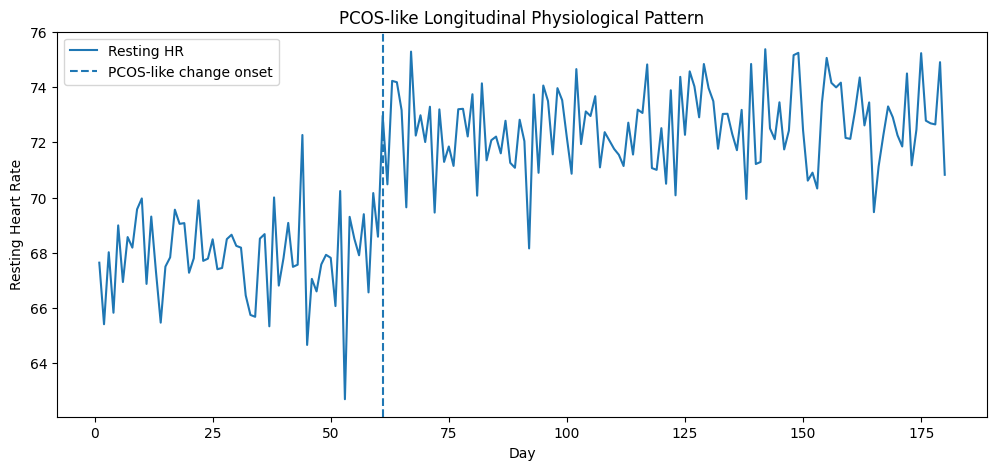

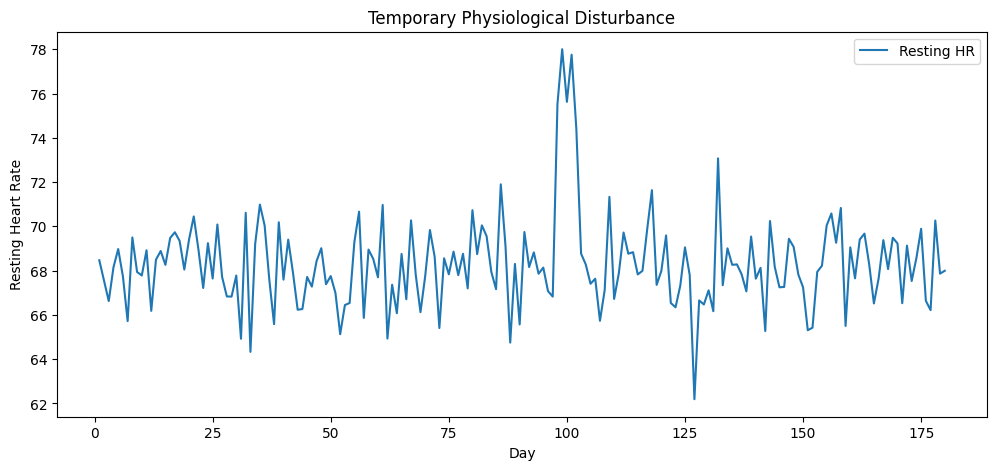


Corrected synthetic dataset saved successfully.
File: ENDO_TWIN_synthetic_dataset.csv


In [7]:
# ============================================================
# 2. SYNTHETIC DATASET GENERATION
# ENDO-TWIN
# ============================================================

# ------------------------------------------------------------
# 2.1 Simulation Parameters
# ------------------------------------------------------------

N_USERS = 400
DAYS = 180

N_NORMAL = 100
N_VARIABLE = 100
N_PCOS_LIKE = 100
N_TEMPORARY = 100

np.random.seed(42)


# ------------------------------------------------------------
# 2.2 Physiological Baseline Ranges
# ------------------------------------------------------------

BASELINE_RANGES = {
    "resting_hr": (60, 72),
    "hrv": (35, 65),
    "sleep_hours": (6.8, 8.0),
    "temperature": (36.4, 36.8),
    "activity": (5000, 9000)
}


# ------------------------------------------------------------
# 2.3 Create User Groups
# ------------------------------------------------------------

users = []

for i in range(1, N_USERS + 1):

    if i <= N_NORMAL:
        group = "normal"

    elif i <= N_NORMAL + N_VARIABLE:
        group = "variable"

    elif i <= N_NORMAL + N_VARIABLE + N_PCOS_LIKE:
        group = "pcos_like"

    else:
        group = "temporary_disturbance"

    users.append({
        "user_id": f"U{i:03d}",
        "group": group
    })

users_df = pd.DataFrame(users)

print("Users created:")
display(users_df.head())

print("\nUsers per group:")
display(users_df["group"].value_counts())


# ------------------------------------------------------------
# 2.4 Generate Longitudinal Synthetic Data
# ------------------------------------------------------------

records = []

for _, user in users_df.iterrows():

    user_id = user["user_id"]
    group = user["group"]

    # --------------------------------------------------------
    # Individual baseline
    # Each person starts with their own physiological range
    # --------------------------------------------------------

    base_hr = np.random.uniform(60, 72)
    base_hrv = np.random.uniform(35, 65)
    base_sleep = np.random.uniform(6.8, 8.0)
    base_temp = np.random.uniform(36.4, 36.8)
    base_activity = np.random.uniform(5000, 9000)

    # PCOS-like change begins after an initial healthy period
    pcos_onset = 61

    # Temporary disturbance lasts for 5 days
    disturbance_start = np.random.randint(80, 121)
    disturbance_end = disturbance_start + 4

    for day in range(1, DAYS + 1):

        # ----------------------------------------------------
        # Natural day-to-day physiological noise
        # ----------------------------------------------------

        noise_hr = np.random.normal(0, 1.5)
        noise_hrv = np.random.normal(0, 4)
        noise_sleep = np.random.normal(0, 0.25)
        noise_temp = np.random.normal(0, 0.03)
        noise_activity = np.random.normal(0, 700)

        # Default shifts
        hr_shift = 0
        hrv_shift = 0
        sleep_shift = 0
        temp_shift = 0
        activity_shift = 0


        # ====================================================
        # NORMAL GROUP
        # ====================================================

        if group == "normal":

            pass


        # ====================================================
        # VARIABLE GROUP
        # Natural fluctuations without persistent change
        # ====================================================

        elif group == "variable":

            hr_shift = np.random.normal(0, 2)
            hrv_shift = np.random.normal(0, 5)
            sleep_shift = np.random.normal(0, 0.4)
            temp_shift = np.random.normal(0, 0.05)
            activity_shift = np.random.normal(0, 1000)


        # ====================================================
        # PCOS-LIKE GROUP
        # Healthy baseline followed by persistent change
        # ====================================================

        elif group == "pcos_like":

            if day >= pcos_onset:

                hr_shift = 5
                hrv_shift = -12
                sleep_shift = -0.8
                temp_shift = 0.10
                activity_shift = -1800


        # ====================================================
        # TEMPORARY DISTURBANCE GROUP
        # Short-term coordinated physiological disturbance
        # ====================================================

        elif group == "temporary_disturbance":

            if disturbance_start <= day <= disturbance_end:

                hr_shift = 7
                hrv_shift = -15
                sleep_shift = -1.0
                temp_shift = 0.12
                activity_shift = -2200


        # ----------------------------------------------------
        # Calculate physiological measurements
        # ----------------------------------------------------

        resting_hr = np.clip(
            base_hr + hr_shift + noise_hr,
            45,
            100
        )

        hrv = np.clip(
            base_hrv + hrv_shift + noise_hrv,
            10,
            120
        )

        sleep_hours = np.clip(
            base_sleep + sleep_shift + noise_sleep,
            4,
            10
        )

        temperature = np.clip(
            base_temp + temp_shift + noise_temp,
            35.8,
            38.0
        )

        activity = np.clip(
            base_activity + activity_shift + noise_activity,
            500,
            15000
        )


        # ----------------------------------------------------
        # Store record
        # ----------------------------------------------------

        records.append({
            "user_id": user_id,
            "day": day,
            "resting_hr": resting_hr,
            "hrv": hrv,
            "sleep_hours": sleep_hours,
            "temperature": temperature,
            "activity": activity,
            "group": group
        })


# ------------------------------------------------------------
# 2.5 Create DataFrame
# ------------------------------------------------------------

synthetic = pd.DataFrame(records)

print("\nSynthetic dataset generated successfully.")

print("Shape:", synthetic.shape)

print("Number of users:", synthetic["user_id"].nunique())

print("Number of days:", synthetic["day"].nunique())


# ------------------------------------------------------------
# 2.6 Check Group Distribution
# ------------------------------------------------------------

print("\nRows per group:")

display(
    synthetic["group"].value_counts()
)


# ------------------------------------------------------------
# 2.7 Check Missing Values
# ------------------------------------------------------------

print("\nMissing values:")

display(
    synthetic.isnull().sum()
)


# ------------------------------------------------------------
# 2.8 Check Duplicate User-Day Records
# ------------------------------------------------------------

duplicate_count = synthetic.duplicated(
    subset=["user_id", "day"]
).sum()

print(
    "Duplicate user-day records:",
    duplicate_count
)


# ------------------------------------------------------------
# 2.9 Basic Dataset Preview
# ------------------------------------------------------------

print("\nFirst 10 rows:")

display(
    synthetic.head(10).round(2)
)


# ------------------------------------------------------------
# 2.10 Group-wise Physiological Means
# ------------------------------------------------------------

group_means = (
    synthetic
    .groupby("group")[
        [
            "resting_hr",
            "hrv",
            "sleep_hours",
            "temperature",
            "activity"
        ]
    ]
    .mean()
)

print("\nMean physiological values by group:")

display(
    group_means.round(2)
)


# ------------------------------------------------------------
# 2.11 Check PCOS-like Transition
# ------------------------------------------------------------

pcos_example = synthetic[
    synthetic["user_id"] == "U201"
]

print("\nPCOS-like example around change onset:")

display(
    pcos_example[
        pcos_example["day"].isin(
            [55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
        )
    ].round(2)
)


# ------------------------------------------------------------
# 2.12 Check Temporary Disturbance
# ------------------------------------------------------------

temp_example = synthetic[
    synthetic["user_id"] == "U301"
]

print("\nTemporary disturbance example:")

display(
    temp_example[
        temp_example["day"].between(75, 130)
    ].round(2)
)


# ------------------------------------------------------------
# 2.13 Plot PCOS-like Longitudinal Pattern
# ------------------------------------------------------------

pcos_example = synthetic[
    synthetic["user_id"] == "U201"
]

plt.figure(figsize=(12, 5))

plt.plot(
    pcos_example["day"],
    pcos_example["resting_hr"],
    label="Resting HR"
)

plt.axvline(
    61,
    linestyle="--",
    label="PCOS-like change onset"
)

plt.title(
    "PCOS-like Longitudinal Physiological Pattern"
)

plt.xlabel("Day")

plt.ylabel("Resting Heart Rate")

plt.legend()

plt.show()


# ------------------------------------------------------------
# 2.14 Plot Temporary Disturbance
# ------------------------------------------------------------

temp_example = synthetic[
    synthetic["user_id"] == "U301"
]

plt.figure(figsize=(12, 5))

plt.plot(
    temp_example["day"],
    temp_example["resting_hr"],
    label="Resting HR"
)

plt.title(
    "Temporary Physiological Disturbance"
)

plt.xlabel("Day")

plt.ylabel("Resting Heart Rate")

plt.legend()

plt.show()


# ------------------------------------------------------------
# 2.15 Save Dataset
# ------------------------------------------------------------

synthetic.to_csv(
    "ENDO_TWIN_synthetic_dataset.csv",
    index=False
)

print(
    "\nCorrected synthetic dataset saved successfully."
)

print(
    "File: ENDO_TWIN_synthetic_dataset.csv"
)

**DATA GENERATION**
Each simulated participant receives an individual physiological baseline.
The four groups are generated differently:
- Normal: small day-to-day fluctuations around the personal baseline.
- Variable: greater but still natural fluctuations.
- PCOS-like: persistent correlated deviations across multiple physiological signals.
- Temporary disturbance: a short multi-signal disturbance followed by recovery.

The purpose is to test whether longitudinal deviation monitoring can distinguish persistent changes from temporary disturbances.

In [8]:
# Create participant IDs and assign groups
users = []
for i in range(1, N_USERS + 1):
    if i <= N_NORMAL:
        group = "normal"
    elif i <= N_NORMAL + N_VARIABLE:
        group = "variable"
    elif i <= N_NORMAL + N_VARIABLE + N_PCOS_LIKE:
        group = "pcos_like"
    else:
        group = "temporary_disturbance"

    users.append({
        "user_id": f"U{i:03d}",
        "group": group
    })
users_df = pd.DataFrame(users)
print(users_df["group"].value_counts())

# Generate synthetic longitudinal physiological data
records = []
for _, user in users_df.iterrows():

    user_id = user["user_id"]
    group = user["group"]
    # Personal baseline
    base_hr = np.random.uniform(60, 72)
    base_hrv = np.random.uniform(35, 65)
    base_sleep = np.random.uniform(6.8, 8.0)
    base_temp = np.random.uniform(36.4, 36.8)
    base_activity = np.random.uniform(5000, 9000)
    # Start temporary disturbance at a random point
    disturbance_start = np.random.randint(60, 120)
    disturbance_end = disturbance_start + 5
    for day in range(1, DAYS + 1):
        # Small normal biological variation
        noise_hr = np.random.normal(0, 1.5)
        noise_hrv = np.random.normal(0, 4)
        noise_sleep = np.random.normal(0, 0.25)
        noise_temp = np.random.normal(0, 0.03)
        noise_activity = np.random.normal(0, 700)
        # Default deviations
        hr_shift = 0
        hrv_shift = 0
        sleep_shift = 0
        temp_shift = 0
        activity_shift = 0

        # NORMAL GROUP
        # ------------------------------------------------
        if group == "normal":

            pass

        # ------------------------------------------------
        # VARIABLE GROUP
        # ------------------------------------------------
        elif group == "variable":

            hr_shift = np.random.normal(0, 2)
            hrv_shift = np.random.normal(0, 5)
            sleep_shift = np.random.normal(0, 0.4)
            temp_shift = np.random.normal(0, 0.05)
            activity_shift = np.random.normal(0, 1000)

        # ------------------------------------------------
        # PCOS-LIKE GROUP
        # ------------------------------------------------
        elif group == "pcos_like":

            # Persistent correlated physiological deviation
            hr_shift = 5
            hrv_shift = -12
            sleep_shift = -0.8
            temp_shift = 0.10
            activity_shift = -1800

        # ------------------------------------------------
        # TEMPORARY DISTURBANCE GROUP
        # ------------------------------------------------
        elif group == "temporary_disturbance":

            if disturbance_start <= day <= disturbance_end:

                hr_shift = 7
                hrv_shift = -15
                sleep_shift = -1.0
                temp_shift = 0.12
                activity_shift = -2200

        # Final physiological values
        resting_hr = base_hr + hr_shift + noise_hr
        hrv = base_hrv + hrv_shift + noise_hrv
        sleep_hours = base_sleep + sleep_shift + noise_sleep
        temperature = base_temp + temp_shift + noise_temp
        activity = base_activity + activity_shift + noise_activity

        # Keep values physiologically reasonable
        resting_hr = np.clip(resting_hr, 45, 100)
        hrv = np.clip(hrv, 10, 120)
        sleep_hours = np.clip(sleep_hours, 4, 10)
        temperature = np.clip(temperature, 35.8, 38.0)
        activity = np.clip(activity, 500, 15000)

        records.append({
            "user_id": user_id,
            "day": day,
            "resting_hr": resting_hr,
            "hrv": hrv,
            "sleep_hours": sleep_hours,
            "temperature": temperature,
            "activity": activity,
            "group": group
        })
synthetic = pd.DataFrame(records)
print("Synthetic dataset created.")
print("Shape:", synthetic.shape)

display(synthetic.head(10))
print(synthetic["group"].value_counts())

group
normal                   100
variable                 100
pcos_like                100
temporary_disturbance    100
Name: count, dtype: int64
Synthetic dataset created.
Shape: (72000, 8)


,user_id,day,resting_hr,hrv,sleep_hours,temperature,activity,group
0,U001,1,59.051154,51.838760,7.754121,36.528200,6380.883500,normal
1,U001,2,61.150443,50.985514,7.959732,36.506496,6775.678203,normal
2,U001,3,60.714355,55.122163,7.722676,36.533066,7433.503746,normal
3,U001,4,61.109037,68.645456,7.326056,36.539207,8182.515111,normal
4,U001,5,62.064387,59.468081,7.675457,36.504811,7729.227958,normal
5,U001,6,60.978797,61.376721,7.183266,36.521341,6397.951282,normal
6,U001,7,61.658669,50.490580,8.011816,36.578191,7356.665711,normal
7,U001,8,59.289663,53.013776,7.873454,36.503767,6337.487705,normal
8,U001,9,61.885826,53.297442,7.596995,36.555770,6709.610821,normal
9,U001,10,59.496331,62.632043,7.734416,36.554051,7069.242777,normal


group
normal                   18000
variable                 18000
pcos_like                18000
temporary_disturbance    18000
Name: count, dtype: int64


**SAVING THE DATASET AND CHECKING MISSING VALUES**

In [9]:
# Save synthetic dataset
synthetic.to_csv("ENDO_TWIN_synthetic_dataset.csv", index=False)
print("Synthetic dataset saved successfully.")
print("File: ENDO_TWIN_synthetic_dataset.csv")

Synthetic dataset saved successfully.
File: ENDO_TWIN_synthetic_dataset.csv


In [10]:
# Verify saved dataset
import os
print("File exists:", os.path.exists("ENDO_TWIN_synthetic_dataset.csv"))
print("File size:", round(os.path.getsize("ENDO_TWIN_synthetic_dataset.csv") / 1024, 2), "KB")

File exists: True
File size: 7789.44 KB


In [11]:
# Check missing values
print("Missing values:")
print(synthetic.isnull().sum())

# Check duplicate participant-day records
duplicates = synthetic.duplicated(
    subset=["user_id", "day"]
).sum()
print("Duplicate participant-day records:", duplicates)

# Check ranges of physiological variables
print("Physiological ranges:\n")
for column in [
    "resting_hr",
    "hrv",
    "sleep_hours",
    "temperature",
    "activity"
]:
    print(
        column,
        "→ min:",
        round(synthetic[column].min(), 2),
        "| max:",
        round(synthetic[column].max(), 2)
    )

# Compare average physiological signals between groups
group_summary = synthetic.groupby("group")[
    [
        "resting_hr",
        "hrv",
        "sleep_hours",
        "temperature",
        "activity"
    ]
].mean()
display(group_summary.round(2))

# Look at one temporary-disturbance participant
temp_user = synthetic[
    synthetic["user_id"] == "U301"
].copy()
display(temp_user.head(10))

# Show the period around the temporary disturbance
display(
    temp_user[
        (temp_user["day"] >= 55) &
        (temp_user["day"] <= 75)
    ]
)

Missing values:
user_id        0
day            0
resting_hr     0
hrv            0
sleep_hours    0
temperature    0
activity       0
group          0
dtype: int64
Duplicate participant-day records: 0
Physiological ranges:

resting_hr → min: 52.26 | max: 81.84
hrv → min: 10.0 | max: 87.06
sleep_hours → min: 5.23 | max: 9.43
temperature → min: 36.23 | max: 36.99
activity → min: 800.23 | max: 12782.88


,resting_hr,hrv,sleep_hours,temperature,activity
group,,,,,
normal,65.80,49.69,7.39,36.58,6902.51
pcos_like,71.23,38.10,6.52,36.70,5101.41
temporary_disturbance,65.62,49.78,7.40,36.61,7095.00
variable,66.07,51.40,7.38,36.61,6830.23


,user_id,day,resting_hr,hrv,sleep_hours,temperature,activity,group
54000,U301,1,67.388723,44.324079,7.582766,36.779659,5859.782650,temporary_disturbance
54001,U301,2,67.176036,47.933027,6.827286,36.817126,6791.867499,temporary_disturbance
54002,U301,3,66.587882,47.393104,7.512332,36.772701,6729.395584,temporary_disturbance
54003,U301,4,65.593140,45.269293,7.515435,36.835664,7136.137550,temporary_disturbance
54004,U301,5,64.743669,35.703706,7.475240,36.819151,6005.151983,temporary_disturbance
54005,U301,6,66.417972,49.418077,7.977407,36.753348,6435.597976,temporary_disturbance
54006,U301,7,65.239991,47.239788,7.390111,36.761725,7101.329829,temporary_disturbance
54007,U301,8,67.120215,55.392114,7.211766,36.748888,7298.332593,temporary_disturbance
54008,U301,9,64.866165,50.235314,7.827265,36.797483,5016.933394,temporary_disturbance
54009,U301,10,64.961164,48.077830,7.058323,36.785792,7209.617233,temporary_disturbance


,user_id,day,resting_hr,hrv,sleep_hours,temperature,activity,group
54054,U301,55,68.707808,46.774421,7.183793,36.817605,8506.259647,temporary_disturbance
54055,U301,56,63.431575,57.559535,7.489696,36.774810,4861.090045,temporary_disturbance
54056,U301,57,63.234424,39.376896,7.673914,36.775456,6623.926988,temporary_disturbance
54057,U301,58,63.703393,43.882896,7.744090,36.742707,6492.270979,temporary_disturbance
54058,U301,59,67.441284,43.215174,7.504681,36.826243,6135.352814,temporary_disturbance
54059,U301,60,67.029573,46.923694,7.209494,36.778060,6362.086229,temporary_disturbance
54060,U301,61,64.709464,41.627041,7.364379,36.785158,6662.484149,temporary_disturbance
54061,U301,62,68.962357,47.228511,7.127079,36.796440,7437.675270,temporary_disturbance
54062,U301,63,65.767263,52.205666,7.205609,36.770643,6367.355656,temporary_disturbance
54063,U301,64,65.950940,44.358741,7.297920,36.786614,6612.883246,temporary_disturbance


**EXPLORATORY DATA ANALYSIS**
The synthetic dataset is visualized to examine individual longitudinal trajectories and compare physiological patterns across the simulated groups.
The focus is on temporal behavior rather than only differences in group averages.

4. EXPLORATORY DATA ANALYSIS

--- 4.1 Basic Dataset Information ---
Dataset shape: (72000, 8)

Column names:
['user_id', 'day', 'resting_hr', 'hrv', 'sleep_hours', 'temperature', 'activity', 'group']

Data types:
user_id         object
day              int64
resting_hr     float64
hrv            float64
sleep_hours    float64
temperature    float64
activity       float64
group           object
dtype: object

Missing values:
user_id        0
day            0
resting_hr     0
hrv            0
sleep_hours    0
temperature    0
activity       0
group          0
dtype: int64

Number of unique users: 400

Group distribution:
group
normal                   18000
variable                 18000
pcos_like                18000
temporary_disturbance    18000
Name: count, dtype: int64

--- 4.2 Descriptive Statistics ---


,resting_hr,hrv,sleep_hours,temperature,activity
count,72000.00,72000.00,72000.00,72000.00,72000.00
mean,67.18,47.24,7.17,36.62,6482.29
std,4.59,11.36,0.61,0.13,1676.82
min,52.26,10.00,5.23,36.23,800.23
25%,63.65,39.21,6.75,36.53,5359.76
50%,67.05,47.36,7.20,36.62,6484.10
75%,70.41,55.74,7.62,36.72,7678.83
max,81.84,87.06,9.43,36.99,12782.88



--- 4.3 Group-wise Physiological Comparison ---


,resting_hr,hrv,sleep_hours,temperature,activity
group,,,,,
normal,65.80,49.69,7.39,36.58,6902.51
pcos_like,71.23,38.10,6.52,36.70,5101.41
temporary_disturbance,65.62,49.78,7.40,36.61,7095.00
variable,66.07,51.40,7.38,36.61,6830.23



--- 4.4 Group Comparison Plots ---


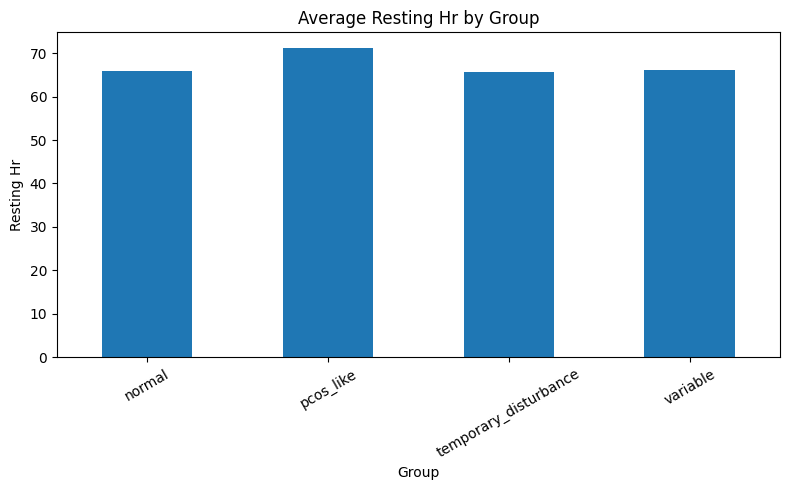

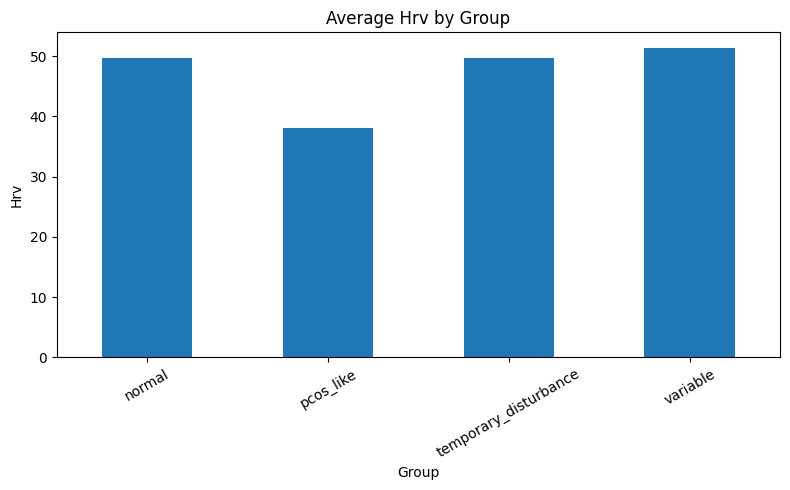

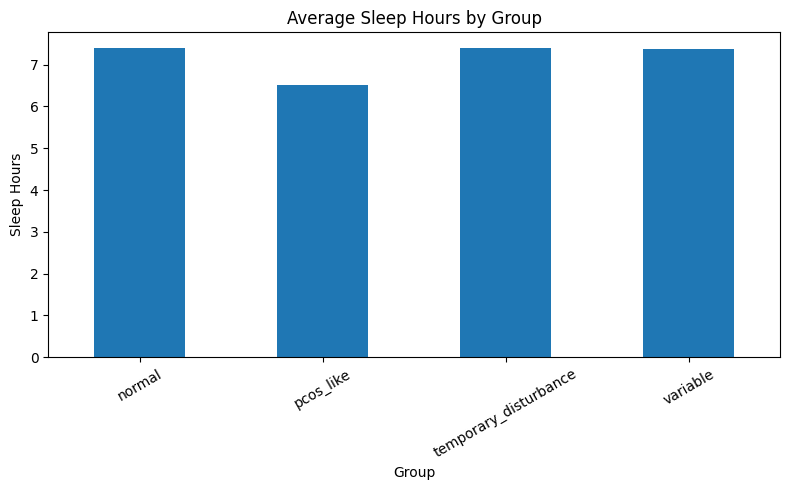

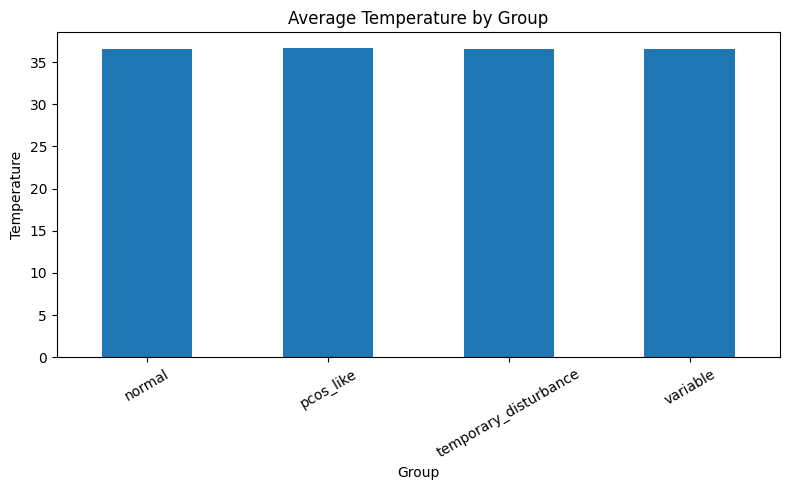

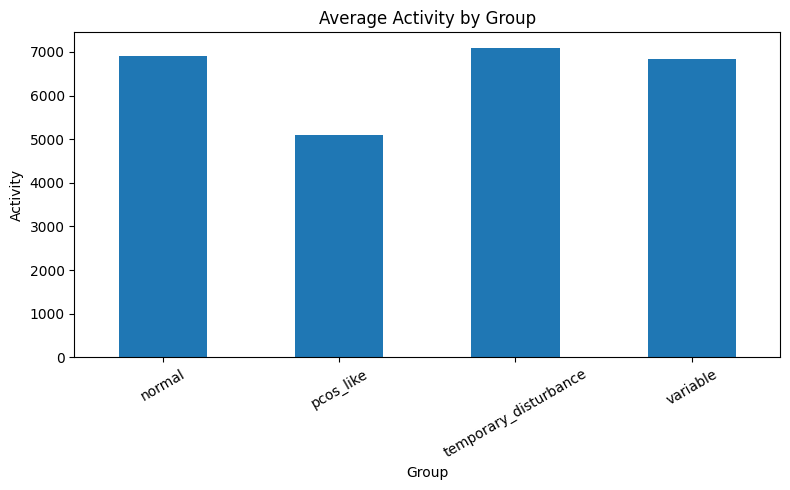


--- 4.5 Correlation Between Physiological Features ---


,resting_hr,hrv,sleep_hours,temperature,activity
resting_hr,1.00,-0.32,-0.31,0.18,-0.32
hrv,-0.32,1.00,0.28,-0.16,0.26
sleep_hours,-0.31,0.28,1.00,-0.19,0.29
temperature,0.18,-0.16,-0.19,1.00,-0.17
activity,-0.32,0.26,0.29,-0.17,1.00


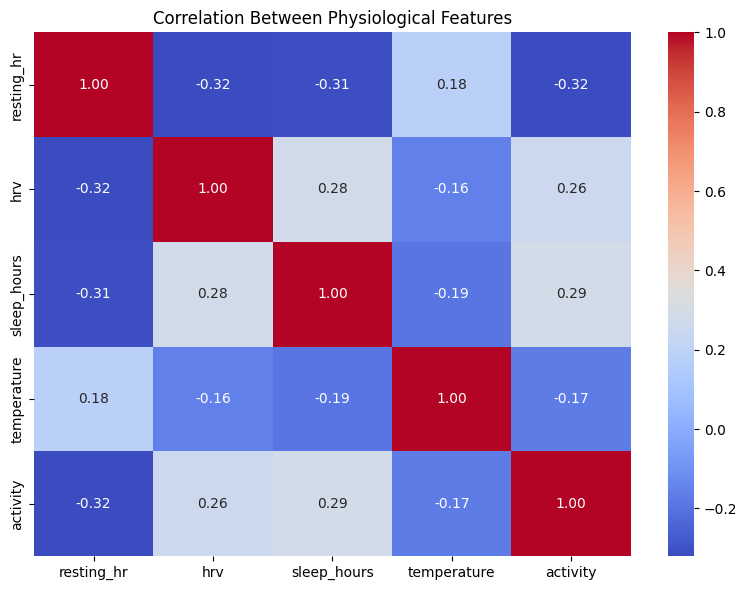


--- 4.6 Normal User Longitudinal Pattern ---


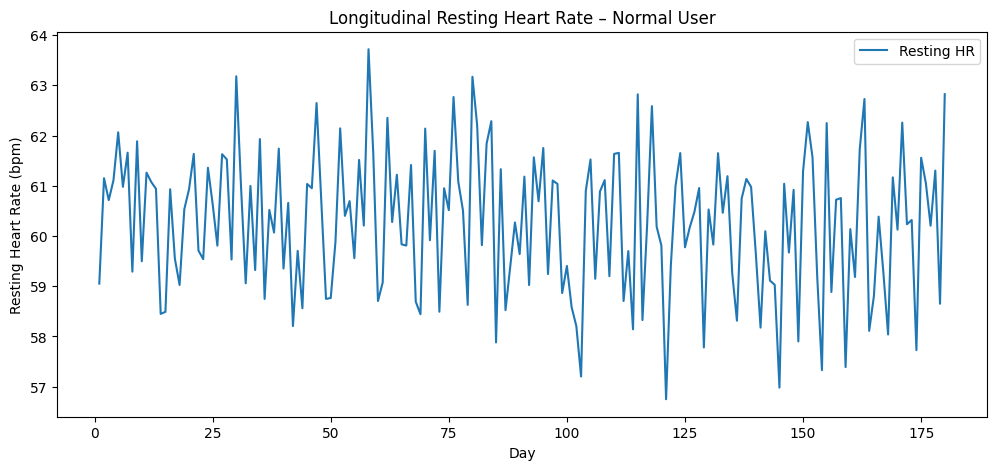


--- 4.7 PCOS-like User Longitudinal Pattern ---


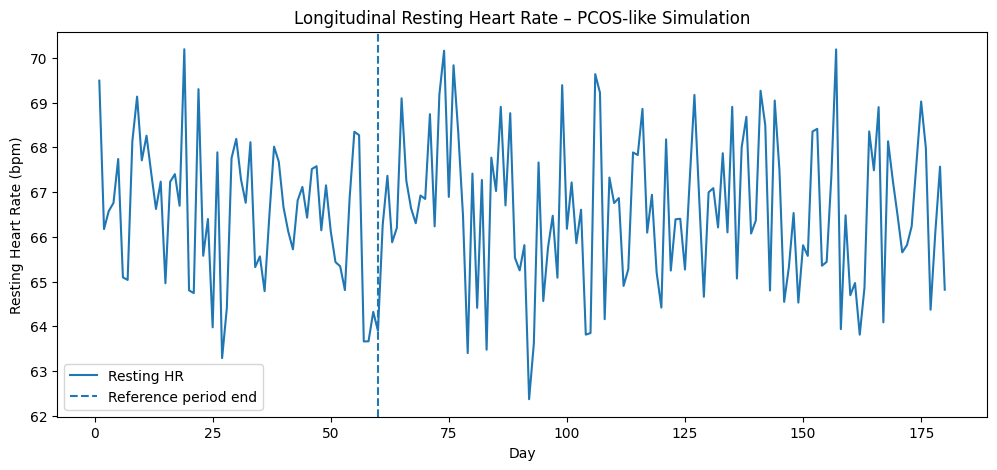


--- 4.8 PCOS-like Changes Around Onset ---


,day,resting_hr,hrv,sleep_hours,temperature,activity
36049,50,66.13,27.42,7.16,36.74,3075.44
36050,51,65.44,29.28,7.19,36.76,3919.59
36051,52,65.34,29.32,6.99,36.78,4226.14
36052,53,64.81,36.10,6.76,36.74,4296.33
36053,54,66.86,36.21,6.77,36.74,3892.05
36054,55,68.35,31.79,7.16,36.83,3401.03
36055,56,68.27,32.34,6.84,36.76,2815.91
36056,57,63.66,32.89,6.97,36.79,3021.38
36057,58,63.67,28.12,6.86,36.76,2712.65
36058,59,64.32,33.37,6.87,36.74,3836.77



--- 4.9 Temporary Disturbance Pattern ---


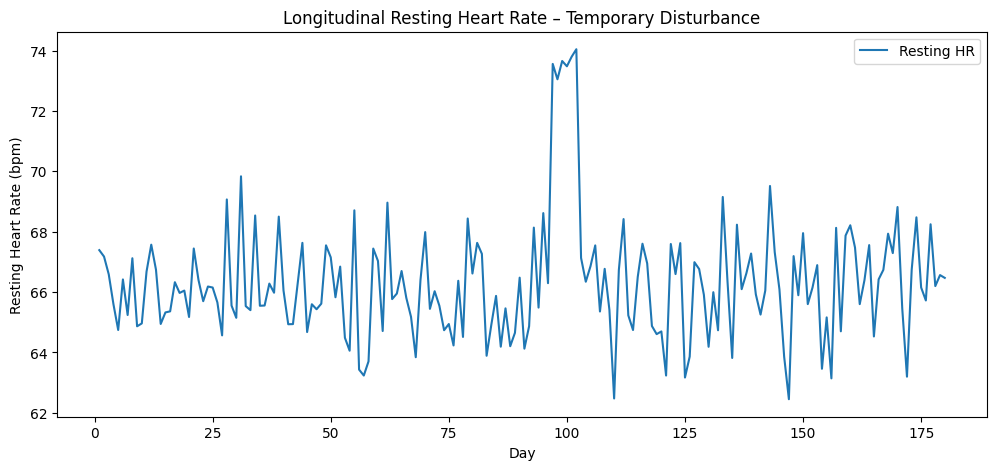


EDA SUMMARY

The exploratory analysis shows that the synthetic dataset contains
longitudinal physiological measurements for four simulated groups.

The normal group shows relatively stable physiological patterns,
while the variable group shows greater natural fluctuations.

The PCOS-like simulation shows a sustained change in multiple
physiological features after the defined reference period.

The temporary disturbance group shows a short-term change followed
by recovery.

These observations support the use of personalized baseline modelling
and longitudinal deviation analysis in the subsequent ENDO-TWIN stages.

The synthetic data are used for model development and testing and
do not represent clinical evidence of PCOS.



In [12]:
# ============================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("=" * 60)
print("4. EXPLORATORY DATA ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 4.1 BASIC DATASET INFORMATION
# ------------------------------------------------------------

print("\n--- 4.1 Basic Dataset Information ---")

print("Dataset shape:", synthetic.shape)

print("\nColumn names:")
print(synthetic.columns.tolist())

print("\nData types:")
print(synthetic.dtypes)

print("\nMissing values:")
print(synthetic.isnull().sum())

print("\nNumber of unique users:",
      synthetic["user_id"].nunique())

print("\nGroup distribution:")
print(synthetic["group"].value_counts())


# ------------------------------------------------------------
# 4.2 DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

print("\n--- 4.2 Descriptive Statistics ---")

features = [
    "resting_hr",
    "hrv",
    "sleep_hours",
    "temperature",
    "activity"
]

display(
    synthetic[features]
    .describe()
    .round(2)
)


# ------------------------------------------------------------
# 4.3 GROUP-WISE PHYSIOLOGICAL COMPARISON
# ------------------------------------------------------------

print("\n--- 4.3 Group-wise Physiological Comparison ---")

group_summary = (
    synthetic
    .groupby("group")[features]
    .mean()
    .round(2)
)

display(group_summary)


# ------------------------------------------------------------
# 4.4 VISUALIZE GROUP DIFFERENCES
# ------------------------------------------------------------

print("\n--- 4.4 Group Comparison Plots ---")

for feature in features:

    plt.figure(figsize=(8, 5))

    synthetic.groupby("group")[feature].mean().plot(
        kind="bar"
    )

    plt.title(
        f"Average {feature.replace('_', ' ').title()} by Group"
    )

    plt.xlabel("Group")
    plt.ylabel(feature.replace("_", " ").title())

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4.5 CORRELATION ANALYSIS
# ------------------------------------------------------------

print("\n--- 4.5 Correlation Between Physiological Features ---")

correlation = synthetic[features].corr()

display(correlation.round(2))


# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Physiological Features")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4.6 LONGITUDINAL ANALYSIS – NORMAL USER
# ------------------------------------------------------------

print("\n--- 4.6 Normal User Longitudinal Pattern ---")

normal_user = synthetic[
    synthetic["user_id"] == "U001"
]

plt.figure(figsize=(12, 5))

plt.plot(
    normal_user["day"],
    normal_user["resting_hr"],
    label="Resting HR"
)

plt.title(
    "Longitudinal Resting Heart Rate – Normal User"
)

plt.xlabel("Day")
plt.ylabel("Resting Heart Rate (bpm)")

plt.legend()
plt.show()


# ------------------------------------------------------------
# 4.7 LONGITUDINAL ANALYSIS – PCOS-LIKE USER
# ------------------------------------------------------------

print("\n--- 4.7 PCOS-like User Longitudinal Pattern ---")

pcos_user = synthetic[
    synthetic["user_id"] == "U201"
]

plt.figure(figsize=(12, 5))

plt.plot(
    pcos_user["day"],
    pcos_user["resting_hr"],
    label="Resting HR"
)

plt.axvline(
    60,
    linestyle="--",
    label="Reference period end"
)

plt.title(
    "Longitudinal Resting Heart Rate – PCOS-like Simulation"
)

plt.xlabel("Day")
plt.ylabel("Resting Heart Rate (bpm)")

plt.legend()
plt.show()


# ------------------------------------------------------------
# 4.8 PCOS-LIKE PHYSIOLOGICAL CHANGES AROUND ONSET
# ------------------------------------------------------------

print("\n--- 4.8 PCOS-like Changes Around Onset ---")

pcos_example = pcos_user[
    pcos_user["day"].between(50, 75)
]

display(
    pcos_example[
        [
            "day",
            "resting_hr",
            "hrv",
            "sleep_hours",
            "temperature",
            "activity"
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 4.9 TEMPORARY DISTURBANCE ANALYSIS
# ------------------------------------------------------------

print("\n--- 4.9 Temporary Disturbance Pattern ---")

temporary_user = synthetic[
    synthetic["user_id"] == "U301"
]

plt.figure(figsize=(12, 5))

plt.plot(
    temporary_user["day"],
    temporary_user["resting_hr"],
    label="Resting HR"
)

plt.title(
    "Longitudinal Resting Heart Rate – Temporary Disturbance"
)

plt.xlabel("Day")
plt.ylabel("Resting Heart Rate (bpm)")

plt.legend()
plt.show()


# ------------------------------------------------------------
# 4.10 EDA SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print("""
The exploratory analysis shows that the synthetic dataset contains
longitudinal physiological measurements for four simulated groups.

The normal group shows relatively stable physiological patterns,
while the variable group shows greater natural fluctuations.

The PCOS-like simulation shows a sustained change in multiple
physiological features after the defined reference period.

The temporary disturbance group shows a short-term change followed
by recovery.

These observations support the use of personalized baseline modelling
and longitudinal deviation analysis in the subsequent ENDO-TWIN stages.

The synthetic data are used for model development and testing and
do not represent clinical evidence of PCOS.
""")

**5. ENDOTWIN PERSONAL BASELINE**

ENDO-TWIN uses an individual's own historical physiological measurements as the reference point.
This personalized baseline allows the model to detect deviations relative to the individual's expected physiological state rather than relying only on population-level thresholds.
The core physiological features are:
- Resting heart rate
- Heart rate variability
- Sleep duration
- Skin temperature
- Physical activity


In [13]:
# Remove all duplicate/suffixed baseline columns
# and rebuild synthetic from the original saved dataset.

synthetic = pd.read_csv("ENDO_TWIN_synthetic_dataset.csv")

print("Original dataset restored.")
print("Shape:", synthetic.shape)
print("Columns:")
print(synthetic.columns.tolist())

Original dataset restored.
Shape: (72000, 8)
Columns:
['user_id', 'day', 'resting_hr', 'hrv', 'sleep_hours', 'temperature', 'activity', 'group']


In [14]:
# ============================================================
# 5. ENDO-TWIN PERSONAL BASELINE
# ============================================================

print("\n" + "=" * 60)
print("5. ENDO-TWIN PERSONAL BASELINE")
print("=" * 60)


# ------------------------------------------------------------
# 5.1 REMOVE OLD BASELINE COLUMNS IF THEY EXIST
# ------------------------------------------------------------

baseline_columns = [
    "resting_hr_baseline",
    "hrv_baseline",
    "sleep_hours_baseline",
    "temperature_baseline",
    "activity_baseline",
    "resting_hr_std",
    "hrv_std",
    "sleep_hours_std",
    "temperature_std",
    "activity_std"
]

synthetic = synthetic.drop(
    columns=[
        col for col in baseline_columns
        if col in synthetic.columns
    ]
)


# ------------------------------------------------------------
# 5.2 DEFINE REFERENCE PERIOD
# ------------------------------------------------------------

REFERENCE_START = 1
REFERENCE_END = 60

reference_data = synthetic[
    synthetic["day"].between(
        REFERENCE_START,
        REFERENCE_END
    )
].copy()

print(
    f"\nReference period: "
    f"Day {REFERENCE_START} to Day {REFERENCE_END}"
)

print(
    "Reference records:",
    len(reference_data)
)


# ------------------------------------------------------------
# 5.3 FEATURES
# ------------------------------------------------------------

features = [
    "resting_hr",
    "hrv",
    "sleep_hours",
    "temperature",
    "activity"
]


# ------------------------------------------------------------
# 5.4 PERSONAL BASELINE
# ------------------------------------------------------------

personal_baseline = (
    reference_data
    .groupby("user_id")[features]
    .mean()
    .reset_index()
)

personal_baseline = personal_baseline.rename(
    columns={
        feature: feature + "_baseline"
        for feature in features
    }
)


# ------------------------------------------------------------
# 5.5 PERSONAL VARIABILITY
# ------------------------------------------------------------

personal_variability = (
    reference_data
    .groupby("user_id")[features]
    .std()
    .reset_index()
)

personal_variability = personal_variability.rename(
    columns={
        feature: feature + "_std"
        for feature in features
    }
)


# ------------------------------------------------------------
# 5.6 COMBINE BASELINE + VARIABILITY
# ------------------------------------------------------------

baseline_table = personal_baseline.merge(
    personal_variability,
    on="user_id"
)

print("\nPersonal baseline table:")

display(
    baseline_table.head().round(3)
)


# ------------------------------------------------------------
# 5.7 ADD BASELINE TO DAILY DATA
# ------------------------------------------------------------

synthetic = synthetic.merge(
    baseline_table,
    on="user_id",
    how="left"
)

print(
    "\nBaseline information added successfully."
)

print(
    "Updated dataset shape:",
    synthetic.shape
)


# ------------------------------------------------------------
# 5.8 CHECK U001
# ------------------------------------------------------------

print("\n--- U001 Personal Baseline ---")

u001_baseline = baseline_table[
    baseline_table["user_id"] == "U001"
]

display(
    u001_baseline.round(3)
)


# ------------------------------------------------------------
# 5.9 CHECK U001 DAILY VALUES
# ------------------------------------------------------------

print("\n--- U001 First 10 Days ---")

u001_data = synthetic[
    synthetic["user_id"] == "U001"
].copy()

display(
    u001_data[
        [
            "day",

            "resting_hr",
            "resting_hr_baseline",

            "hrv",
            "hrv_baseline",

            "sleep_hours",
            "sleep_hours_baseline",

            "temperature",
            "temperature_baseline",

            "activity",
            "activity_baseline"
        ]
    ].head(10).round(3)
)


# ------------------------------------------------------------
# 5.10 VERIFY BASELINE RECORD COUNT
# ------------------------------------------------------------

print("\n--- Baseline Verification ---")

print(
    "Number of users with baselines:",
    baseline_table["user_id"].nunique()
)

print(
    "Expected number of users:",
    synthetic["user_id"].nunique()
)

print(
    "Expected dataset rows:",
    400 * 180
)


# ------------------------------------------------------------
# 5.11 SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SECTION 5 COMPLETE")
print("=" * 60)

print("""
Each user's first 60 days are used as a personalized
reference period.

For every physiological feature, ENDO-TWIN calculates:

1. Personal baseline
   - Average value during the reference period.

2. Personal variability
   - Standard deviation during the reference period.

These values are attached to every daily observation.

This allows ENDO-TWIN to measure future physiological
changes relative to each individual's own baseline rather
than relying only on population-level values.

The first 60 days are a modelling choice for this synthetic
experiment and are not a clinical reference period.
""")


5. ENDO-TWIN PERSONAL BASELINE

Reference period: Day 1 to Day 60
Reference records: 24000

Personal baseline table:


,user_id,resting_hr_baseline,hrv_baseline,sleep_hours_baseline,temperature_baseline,activity_baseline,resting_hr_std,hrv_std,sleep_hours_std,temperature_std,activity_std
0,U001,60.472,54.664,7.632,36.530,6809.852,1.247,4.338,0.235,0.030,669.251
1,U002,69.625,51.698,7.154,36.660,8604.815,1.472,3.615,0.219,0.025,739.885
2,U003,69.321,45.452,7.665,36.563,7706.582,1.270,4.112,0.267,0.028,700.008
3,U004,69.726,49.616,7.428,36.472,7746.026,1.647,4.173,0.243,0.030,717.818
4,U005,63.506,50.965,7.283,36.421,6534.120,1.622,4.320,0.244,0.032,633.947



Baseline information added successfully.
Updated dataset shape: (72000, 18)

--- U001 Personal Baseline ---


,user_id,resting_hr_baseline,hrv_baseline,sleep_hours_baseline,temperature_baseline,activity_baseline,resting_hr_std,hrv_std,sleep_hours_std,temperature_std,activity_std
0,U001,60.472,54.664,7.632,36.53,6809.852,1.247,4.338,0.235,0.03,669.251



--- U001 First 10 Days ---


,day,resting_hr,resting_hr_baseline,hrv,hrv_baseline,sleep_hours,sleep_hours_baseline,temperature,temperature_baseline,activity,activity_baseline
0,1,59.051,60.472,51.839,54.664,7.754,7.632,36.528,36.53,6380.884,6809.852
1,2,61.150,60.472,50.986,54.664,7.960,7.632,36.506,36.53,6775.678,6809.852
2,3,60.714,60.472,55.122,54.664,7.723,7.632,36.533,36.53,7433.504,6809.852
3,4,61.109,60.472,68.645,54.664,7.326,7.632,36.539,36.53,8182.515,6809.852
4,5,62.064,60.472,59.468,54.664,7.675,7.632,36.505,36.53,7729.228,6809.852
5,6,60.979,60.472,61.377,54.664,7.183,7.632,36.521,36.53,6397.951,6809.852
6,7,61.659,60.472,50.491,54.664,8.012,7.632,36.578,36.53,7356.666,6809.852
7,8,59.290,60.472,53.014,54.664,7.873,7.632,36.504,36.53,6337.488,6809.852
8,9,61.886,60.472,53.297,54.664,7.597,7.632,36.556,36.53,6709.611,6809.852
9,10,59.496,60.472,62.632,54.664,7.734,7.632,36.554,36.53,7069.243,6809.852



--- Baseline Verification ---
Number of users with baselines: 400
Expected number of users: 400
Expected dataset rows: 72000

SECTION 5 COMPLETE

Each user's first 60 days are used as a personalized
reference period.

For every physiological feature, ENDO-TWIN calculates:

1. Personal baseline
   - Average value during the reference period.

2. Personal variability
   - Standard deviation during the reference period.

These values are attached to every daily observation.

This allows ENDO-TWIN to measure future physiological
changes relative to each individual's own baseline rather
than relying only on population-level values.

The first 60 days are a modelling choice for this synthetic
experiment and are not a clinical reference period.



**6. PHYSIOLOGICAL DEVIATION DETECTION**
ENDO-TWIN combines personalized deviations across multiple physiological signals into a daily deviation score.
The score represents how different the individual's overall physiological state is from their personal baseline.
A higher score indicates a greater overall deviation, but does not by itself indicate a disease or diagnosis.

In [15]:
# ============================================================
# FIX PCOS-LIKE LONGITUDINAL PATTERN
# ============================================================

print("=" * 60)
print("FIXING PCOS-LIKE SYNTHETIC PATTERN")
print("=" * 60)

# Select PCOS-like observations after the reference period
pcos_mask = (
    (synthetic["group"] == "pcos_like") &
    (synthetic["day"] >= 61)
)

# Apply persistent physiological changes
synthetic.loc[pcos_mask, "resting_hr"] += 5
synthetic.loc[pcos_mask, "hrv"] -= 12
synthetic.loc[pcos_mask, "sleep_hours"] -= 0.8
synthetic.loc[pcos_mask, "temperature"] += 0.10
synthetic.loc[pcos_mask, "activity"] -= 1800

# Keep values within realistic simulation ranges
synthetic["resting_hr"] = synthetic["resting_hr"].clip(45, 100)
synthetic["hrv"] = synthetic["hrv"].clip(10, 120)
synthetic["sleep_hours"] = synthetic["sleep_hours"].clip(4, 10)
synthetic["temperature"] = synthetic["temperature"].clip(35.8, 38)
synthetic["activity"] = synthetic["activity"].clip(500, 15000)

print(
    "PCOS-like shift applied to",
    pcos_mask.sum(),
    "observations."
)

# ------------------------------------------------------------
# VERIFY THE CHANGE
# ------------------------------------------------------------

pcos_check = synthetic[
    synthetic["user_id"] == "U201"
].copy()

print("\n--- U201 Before/After Onset ---")

display(
    pcos_check[
        pcos_check["day"].between(58, 65)
    ][
        [
            "day",
            "resting_hr",
            "hrv",
            "sleep_hours",
            "temperature",
            "activity"
        ]
    ].round(2)
)

print("\nPCOS-like correction complete.")

FIXING PCOS-LIKE SYNTHETIC PATTERN
PCOS-like shift applied to 12000 observations.

--- U201 Before/After Onset ---


,day,resting_hr,hrv,sleep_hours,temperature,activity
36057,58,63.67,28.12,6.86,36.76,2712.65
36058,59,64.32,33.37,6.87,36.74,3836.77
36059,60,63.90,37.31,6.94,36.72,4405.31
36060,61,71.27,22.25,6.08,36.86,1328.85
36061,62,72.36,23.10,6.49,36.85,1223.99
36062,63,70.88,24.07,6.47,36.88,1726.30
36063,64,71.20,27.21,6.56,36.86,1461.25
36064,65,74.09,17.22,6.12,36.90,500.00



PCOS-like correction complete.


6. PHYSIOLOGICAL DEVIATION DETECTION

--- 6.1 Calculating Personalized Deviations ---
Personalized deviations calculated successfully.

--- 6.2 Calculating Absolute Deviations ---
Absolute deviations calculated successfully.

--- 6.3 Calculating Composite Deviation Score ---
Composite deviation score calculated.

--- 6.4 Identifying Significant Deviations ---
Significant deviations: 12541
Percentage of observations with significant deviation: 17.42 %

--- 6.5 Group-wise Deviation Comparison ---


,deviation_score
group,
pcos_like,2.361
temporary_disturbance,0.919
variable,0.810
normal,0.810



--- 6.6 Significant Deviation Rate by Group ---


,significant_deviation
group,
normal,0.01
pcos_like,66.29
temporary_disturbance,3.37
variable,0.01



--- 6.7 Deviation Score Visualization ---


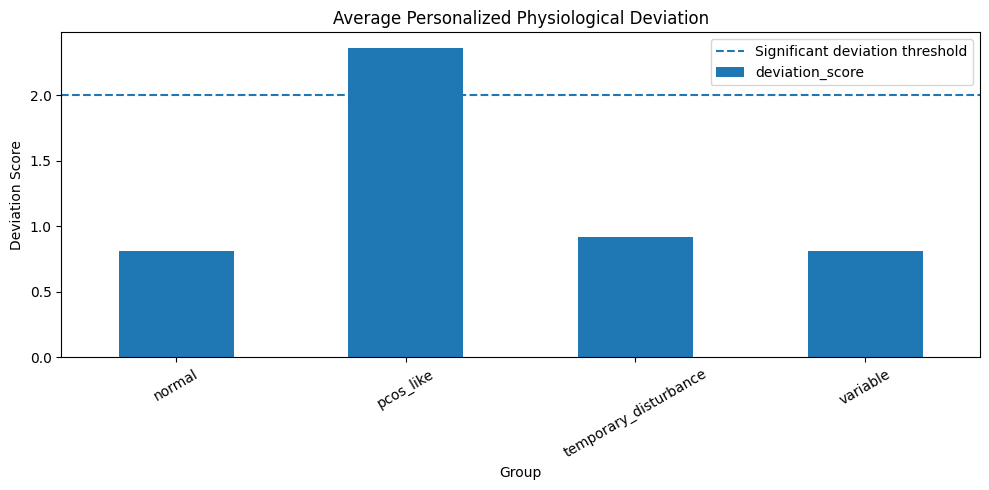


--- 6.8 PCOS-like User Deviation Pattern ---


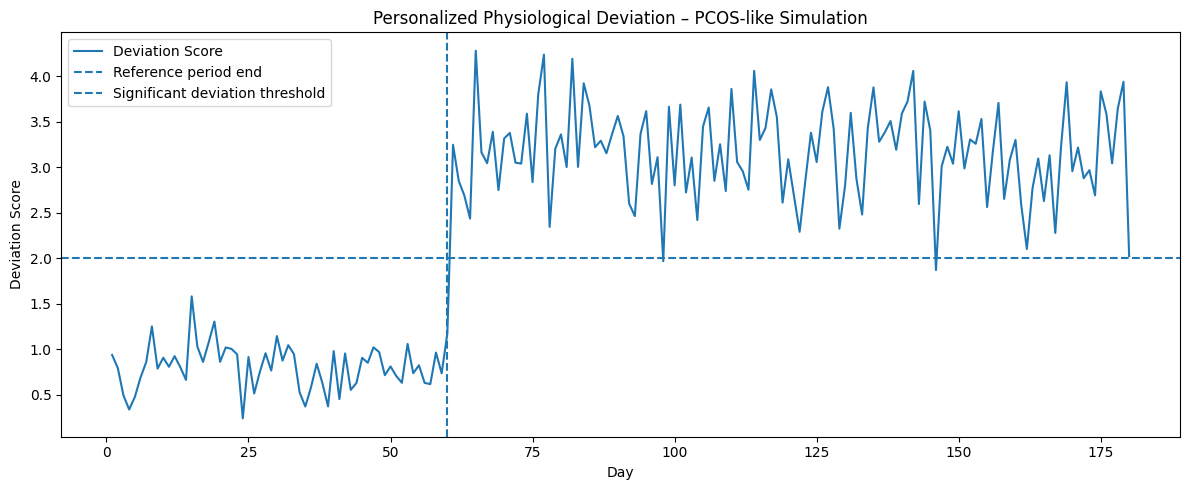


--- 6.9 Temporary Disturbance Deviation Pattern ---


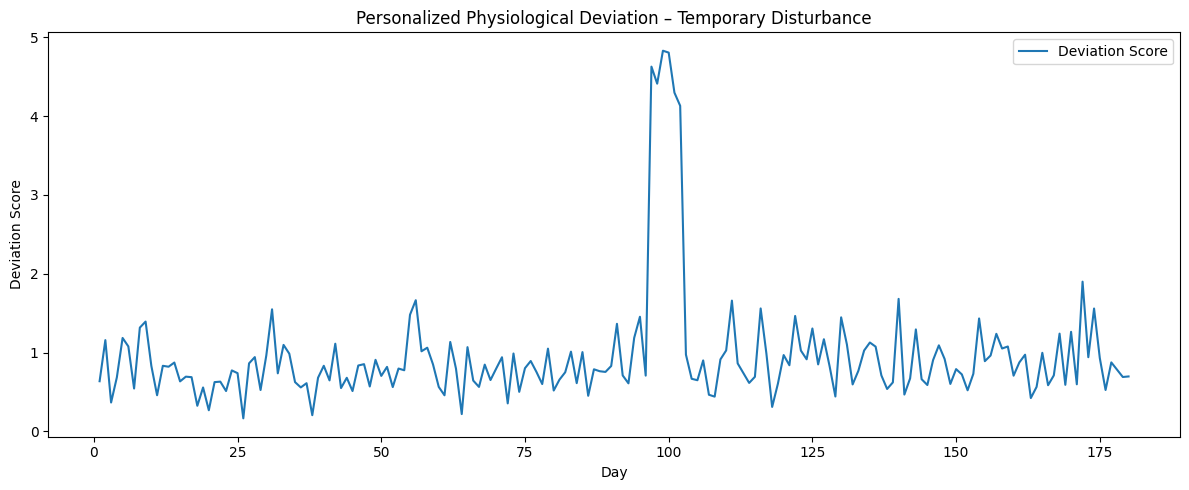


--- 6.10 PCOS-like User Around Onset ---


,day,hr_deviation,hrv_deviation,sleep_deviation,temperature_deviation,activity_deviation,deviation_score,significant_deviation
36054,55,1.15,-0.27,0.87,1.80,-0.02,0.82,0
36055,56,1.11,-0.12,-0.73,-0.37,-0.83,0.63,0
36056,57,-1.83,0.03,-0.11,0.57,-0.54,0.62,0
36057,58,-1.83,-1.27,-0.61,-0.14,-0.97,0.96,0
36058,59,-1.41,0.16,-0.60,-0.93,0.58,0.73,0
36059,60,-1.68,1.22,-0.22,-1.39,1.36,1.17,0
36060,61,3.01,-2.86,-4.50,3.00,-2.87,3.25,1
36061,62,3.71,-2.63,-2.48,2.44,-3.01,2.85,1
36062,63,2.76,-2.37,-2.57,3.41,-2.32,2.69,1
36063,64,2.97,-1.51,-2.12,2.89,-2.69,2.43,1



SECTION 6 COMPLETE

ENDO-TWIN now converts each daily physiological measurement
into a personalized deviation relative to the individual's
own baseline and normal variability.

The five physiological deviations are combined into a
composite deviation score.

This score represents how different the current physiological
state is from the individual's expected personal trajectory.

A threshold of 2 is used only as a modelling threshold for
this synthetic experiment.

The deviation score will be used in the next section to
distinguish persistent physiological changes from short-term
fluctuations.

These synthetic results do not represent clinical evidence
or a diagnostic threshold for PCOS.



In [16]:
# ============================================================
# 6. PHYSIOLOGICAL DEVIATION DETECTION
# ============================================================

print("=" * 60)
print("6. PHYSIOLOGICAL DEVIATION DETECTION")
print("=" * 60)

# ------------------------------------------------------------
# 6.1 CALCULATE STANDARDIZED DEVIATIONS
# ------------------------------------------------------------

print("\n--- 6.1 Calculating Personalized Deviations ---")

# Small value to avoid division by zero
epsilon = 1e-6

synthetic["hr_deviation"] = (
    (synthetic["resting_hr"] - synthetic["resting_hr_baseline"])
    / (synthetic["resting_hr_std"] + epsilon)
)

synthetic["hrv_deviation"] = (
    (synthetic["hrv"] - synthetic["hrv_baseline"])
    / (synthetic["hrv_std"] + epsilon)
)

synthetic["sleep_deviation"] = (
    (synthetic["sleep_hours"] - synthetic["sleep_hours_baseline"])
    / (synthetic["sleep_hours_std"] + epsilon)
)

synthetic["temperature_deviation"] = (
    (synthetic["temperature"] - synthetic["temperature_baseline"])
    / (synthetic["temperature_std"] + epsilon)
)

synthetic["activity_deviation"] = (
    (synthetic["activity"] - synthetic["activity_baseline"])
    / (synthetic["activity_std"] + epsilon)
)

print("Personalized deviations calculated successfully.")


# ------------------------------------------------------------
# 6.2 ABSOLUTE DEVIATIONS
# ------------------------------------------------------------

print("\n--- 6.2 Calculating Absolute Deviations ---")

deviation_columns = [
    "hr_deviation",
    "hrv_deviation",
    "sleep_deviation",
    "temperature_deviation",
    "activity_deviation"
]

for col in deviation_columns:
    synthetic[col + "_abs"] = synthetic[col].abs()

print("Absolute deviations calculated successfully.")


# ------------------------------------------------------------
# 6.3 COMPOSITE PHYSIOLOGICAL DEVIATION SCORE
# ------------------------------------------------------------

print("\n--- 6.3 Calculating Composite Deviation Score ---")

absolute_columns = [
    "hr_deviation_abs",
    "hrv_deviation_abs",
    "sleep_deviation_abs",
    "temperature_deviation_abs",
    "activity_deviation_abs"
]

synthetic["deviation_score"] = synthetic[absolute_columns].mean(axis=1)

print("Composite deviation score calculated.")


# ------------------------------------------------------------
# 6.4 IDENTIFY SIGNIFICANT DEVIATIONS
# ------------------------------------------------------------

print("\n--- 6.4 Identifying Significant Deviations ---")

# A deviation greater than 2 standard deviations
# is considered notable in this synthetic experiment.

synthetic["significant_deviation"] = (
    synthetic["deviation_score"] >= 2
).astype(int)

print(
    "Significant deviations:",
    synthetic["significant_deviation"].sum()
)

print(
    "Percentage of observations with significant deviation:",
    round(
        synthetic["significant_deviation"].mean() * 100,
        2
    ),
    "%"
)


# ------------------------------------------------------------
# 6.5 GROUP-WISE DEVIATION COMPARISON
# ------------------------------------------------------------

print("\n--- 6.5 Group-wise Deviation Comparison ---")

group_deviation = (
    synthetic
    .groupby("group")["deviation_score"]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

display(group_deviation)


# ------------------------------------------------------------
# 6.6 SIGNIFICANT DEVIATION RATE BY GROUP
# ------------------------------------------------------------

print("\n--- 6.6 Significant Deviation Rate by Group ---")

group_significant = (
    synthetic
    .groupby("group")["significant_deviation"]
    .mean()
    .mul(100)
    .round(2)
)

display(group_significant)


# ------------------------------------------------------------
# 6.7 VISUALIZE DEVIATION SCORES
# ------------------------------------------------------------

print("\n--- 6.7 Deviation Score Visualization ---")

plt.figure(figsize=(10, 5))

synthetic.groupby("group")["deviation_score"].mean().plot(
    kind="bar"
)

plt.axhline(
    2,
    linestyle="--",
    label="Significant deviation threshold"
)

plt.title("Average Personalized Physiological Deviation")
plt.xlabel("Group")
plt.ylabel("Deviation Score")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6.8 PCOS-LIKE USER
# ------------------------------------------------------------

print("\n--- 6.8 PCOS-like User Deviation Pattern ---")

pcos_user = synthetic[
    synthetic["user_id"] == "U201"
]

plt.figure(figsize=(12, 5))

plt.plot(
    pcos_user["day"],
    pcos_user["deviation_score"],
    label="Deviation Score"
)

plt.axvline(
    60,
    linestyle="--",
    label="Reference period end"
)

plt.axhline(
    2,
    linestyle="--",
    label="Significant deviation threshold"
)

plt.title(
    "Personalized Physiological Deviation – PCOS-like Simulation"
)

plt.xlabel("Day")
plt.ylabel("Deviation Score")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6.9 TEMPORARY DISTURBANCE USER
# ------------------------------------------------------------

print("\n--- 6.9 Temporary Disturbance Deviation Pattern ---")

temporary_user = synthetic[
    synthetic["user_id"] == "U301"
]

plt.figure(figsize=(12, 5))

plt.plot(
    temporary_user["day"],
    temporary_user["deviation_score"],
    label="Deviation Score"
)

plt.title(
    "Personalized Physiological Deviation – Temporary Disturbance"
)

plt.xlabel("Day")
plt.ylabel("Deviation Score")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6.10 EXAMPLE DEVIATION VALUES
# ------------------------------------------------------------

print("\n--- 6.10 PCOS-like User Around Onset ---")

display(
    pcos_user[
        pcos_user["day"].between(55, 70)
    ][
        [
            "day",
            "hr_deviation",
            "hrv_deviation",
            "sleep_deviation",
            "temperature_deviation",
            "activity_deviation",
            "deviation_score",
            "significant_deviation"
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 6.11 SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SECTION 6 COMPLETE")
print("=" * 60)

print("""
ENDO-TWIN now converts each daily physiological measurement
into a personalized deviation relative to the individual's
own baseline and normal variability.

The five physiological deviations are combined into a
composite deviation score.

This score represents how different the current physiological
state is from the individual's expected personal trajectory.

A threshold of 2 is used only as a modelling threshold for
this synthetic experiment.

The deviation score will be used in the next section to
distinguish persistent physiological changes from short-term
fluctuations.

These synthetic results do not represent clinical evidence
or a diagnostic threshold for PCOS.
""")

In [17]:
# ============================================================
# CHECK PCOS-LIKE SYNTHETIC SHIFT
# ============================================================

pcos_check = synthetic[
    synthetic["user_id"] == "U201"
].copy()

display(
    pcos_check[
        pcos_check["day"].between(55, 65)
    ][
        [
            "day",
            "group",
            "resting_hr",
            "resting_hr_baseline",
            "resting_hr_std",
            "hr_deviation",
            "hrv",
            "hrv_baseline",
            "hrv_deviation",
            "sleep_hours",
            "sleep_hours_baseline",
            "sleep_deviation",
            "temperature",
            "temperature_baseline",
            "temperature_deviation",
            "activity",
            "activity_baseline",
            "activity_deviation"
        ]
    ].round(2)
)

,day,group,resting_hr,resting_hr_baseline,resting_hr_std,hr_deviation,hrv,hrv_baseline,hrv_deviation,sleep_hours,sleep_hours_baseline,sleep_deviation,temperature,temperature_baseline,temperature_deviation,activity,activity_baseline,activity_deviation
36054,55,pcos_like,68.35,66.54,1.57,1.15,31.79,32.8,-0.27,7.16,6.99,0.87,36.83,36.77,1.80,3401.03,3417.46,-0.02
36055,56,pcos_like,68.27,66.54,1.57,1.11,32.34,32.8,-0.12,6.84,6.99,-0.73,36.76,36.77,-0.37,2815.91,3417.46,-0.83
36056,57,pcos_like,63.66,66.54,1.57,-1.83,32.89,32.8,0.03,6.97,6.99,-0.11,36.79,36.77,0.57,3021.38,3417.46,-0.54
36057,58,pcos_like,63.67,66.54,1.57,-1.83,28.12,32.8,-1.27,6.86,6.99,-0.61,36.76,36.77,-0.14,2712.65,3417.46,-0.97
36058,59,pcos_like,64.32,66.54,1.57,-1.41,33.37,32.8,0.16,6.87,6.99,-0.60,36.74,36.77,-0.93,3836.77,3417.46,0.58
36059,60,pcos_like,63.90,66.54,1.57,-1.68,37.31,32.8,1.22,6.94,6.99,-0.22,36.72,36.77,-1.39,4405.31,3417.46,1.36
36060,61,pcos_like,71.27,66.54,1.57,3.01,22.25,32.8,-2.86,6.08,6.99,-4.50,36.86,36.77,3.00,1328.85,3417.46,-2.87
36061,62,pcos_like,72.36,66.54,1.57,3.71,23.10,32.8,-2.63,6.49,6.99,-2.48,36.85,36.77,2.44,1223.99,3417.46,-3.01
36062,63,pcos_like,70.88,66.54,1.57,2.76,24.07,32.8,-2.37,6.47,6.99,-2.57,36.88,36.77,3.41,1726.30,3417.46,-2.32
36063,64,pcos_like,71.20,66.54,1.57,2.97,27.21,32.8,-1.51,6.56,6.99,-2.12,36.86,36.77,2.89,1461.25,3417.46,-2.69


**7. LONGITUDINAL PERSISTENCE MODEL**

7. LONGITUDINAL PERSISTENCE MODEL

--- 7.1 Defining Persistence Window ---
Persistence window: 7 days

--- 7.2 Calculating Rolling Deviation ---
Rolling deviation calculated successfully.

--- 7.3 Counting Recent Significant Deviations ---
Recent significant deviation count calculated.

--- 7.4 Identifying Persistent Deviations ---
Persistent deviation observations: 11999

--- 7.5 Group-wise Persistence ---


,persistent_deviation
group,
normal,0.00
pcos_like,64.44
temporary_disturbance,2.22
variable,0.00



--- 7.6 PCOS-like Persistence Pattern ---


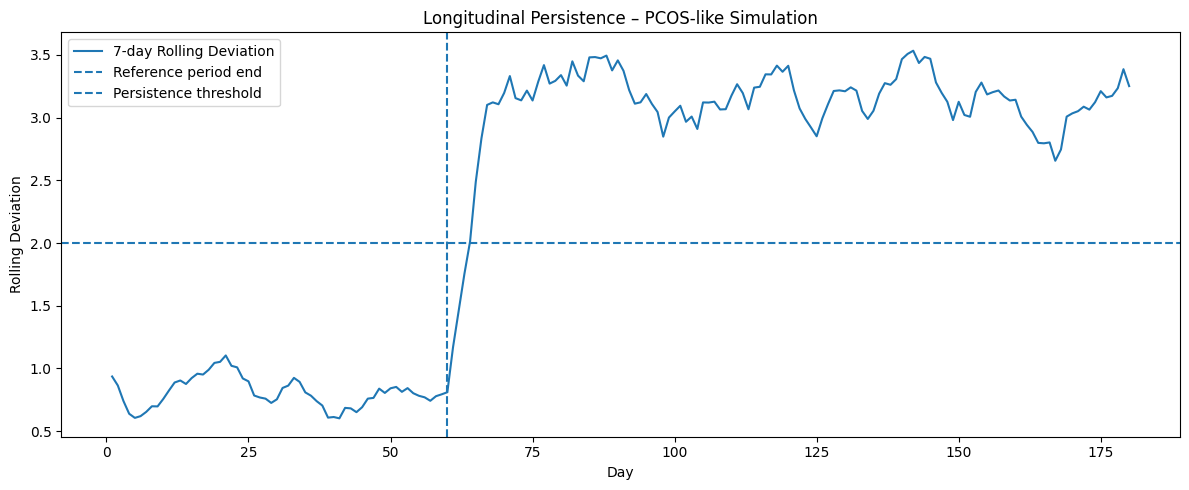


--- 7.7 Temporary Disturbance Persistence Pattern ---


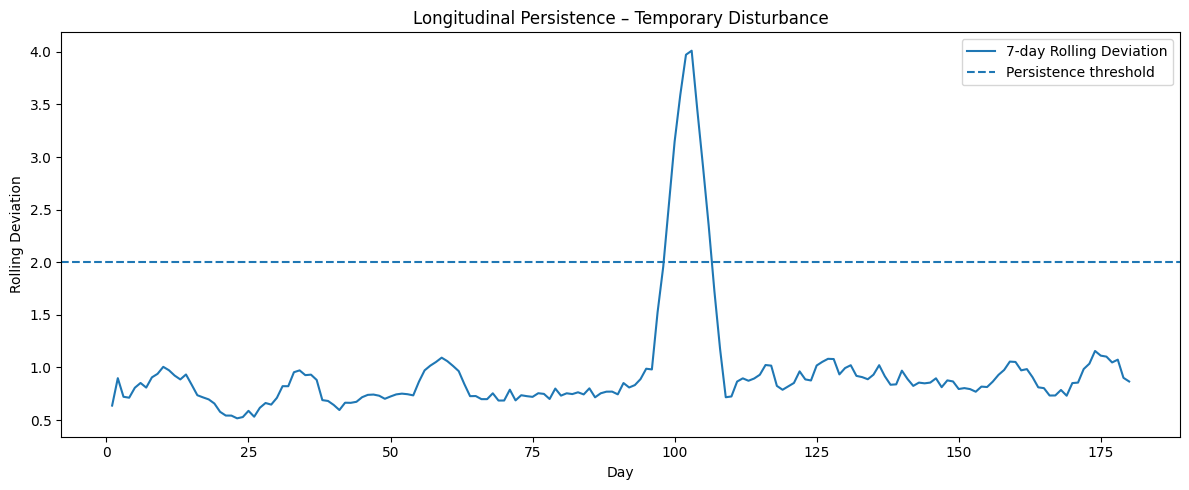


--- 7.8 Comparing Longitudinal States ---


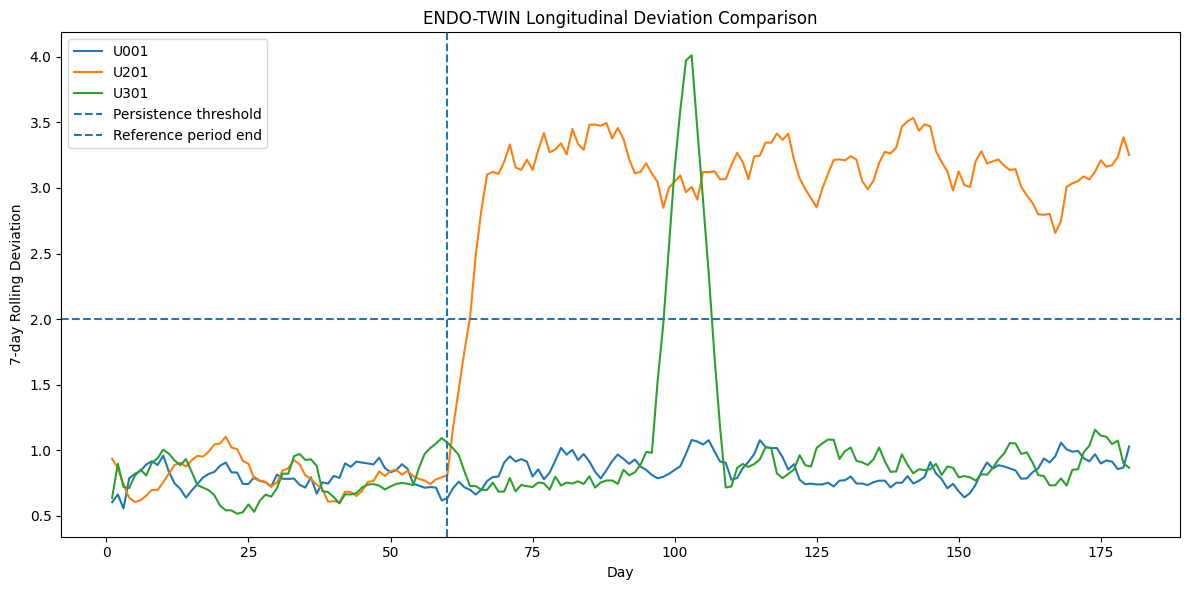


--- 7.9 PCOS-like User Around Onset ---


,day,deviation_score,rolling_deviation,recent_significant_days,persistent_deviation
36057,58,0.96,0.78,0.0,0
36058,59,0.73,0.79,0.0,0
36059,60,1.17,0.81,0.0,0
36060,61,3.25,1.17,1.0,0
36061,62,2.85,1.46,2.0,0
36062,63,2.69,1.75,3.0,0
36063,64,2.43,2.01,4.0,0
36064,65,4.28,2.49,5.0,1
36065,66,3.16,2.83,6.0,1
36066,67,3.04,3.10,7.0,1



SECTION 7 COMPLETE

ENDO-TWIN now evaluates whether physiological deviations
persist over time rather than reacting to isolated changes.

A 7-day rolling deviation is calculated for each individual.

Persistent deviation is identified when the rolling deviation
remains elevated and at least 5 of the previous 7 observations
show significant deviation.

This allows ENDO-TWIN to distinguish sustained physiological
changes from short-term disturbances.

The persistence model is a synthetic modelling framework and
does not represent a clinical diagnostic criterion.



In [18]:
# ============================================================
# 7. LONGITUDINAL PERSISTENCE MODEL
# ============================================================

print("=" * 60)
print("7. LONGITUDINAL PERSISTENCE MODEL")
print("=" * 60)

# ------------------------------------------------------------
# 7.1 DEFINE PERSISTENCE WINDOW
# ------------------------------------------------------------

print("\n--- 7.1 Defining Persistence Window ---")

PERSISTENCE_WINDOW = 7

print("Persistence window:", PERSISTENCE_WINDOW, "days")


# ------------------------------------------------------------
# 7.2 CALCULATE ROLLING DEVIATION
# ------------------------------------------------------------

print("\n--- 7.2 Calculating Rolling Deviation ---")

synthetic = synthetic.sort_values(
    ["user_id", "day"]
).reset_index(drop=True)

synthetic["rolling_deviation"] = (
    synthetic
    .groupby("user_id")["deviation_score"]
    .transform(
        lambda x: x.rolling(
            window=PERSISTENCE_WINDOW,
            min_periods=1
        ).mean()
    )
)

print("Rolling deviation calculated successfully.")


# ------------------------------------------------------------
# 7.3 COUNT RECENT SIGNIFICANT DAYS
# ------------------------------------------------------------

print("\n--- 7.3 Counting Recent Significant Deviations ---")

synthetic["recent_significant_days"] = (
    synthetic
    .groupby("user_id")["significant_deviation"]
    .transform(
        lambda x: x.rolling(
            window=PERSISTENCE_WINDOW,
            min_periods=1
        ).sum()
    )
)

print("Recent significant deviation count calculated.")


# ------------------------------------------------------------
# 7.4 DEFINE PERSISTENT DEVIATION
# ------------------------------------------------------------

print("\n--- 7.4 Identifying Persistent Deviations ---")

# Persistent deviation requires:
# 1. Rolling deviation >= 2
# 2. At least 5 of the previous 7 days are significant

synthetic["persistent_deviation"] = (
    (synthetic["rolling_deviation"] >= 2) &
    (synthetic["recent_significant_days"] >= 5)
).astype(int)

print(
    "Persistent deviation observations:",
    synthetic["persistent_deviation"].sum()
)


# ------------------------------------------------------------
# 7.5 GROUP-WISE PERSISTENCE
# ------------------------------------------------------------

print("\n--- 7.5 Group-wise Persistence ---")

persistence_summary = (
    synthetic
    .groupby("group")["persistent_deviation"]
    .mean()
    .mul(100)
    .round(2)
)

display(persistence_summary)


# ------------------------------------------------------------
# 7.6 PCOS-LIKE PERSISTENCE
# ------------------------------------------------------------

print("\n--- 7.6 PCOS-like Persistence Pattern ---")

pcos_user = synthetic[
    synthetic["user_id"] == "U201"
]

plt.figure(figsize=(12, 5))

plt.plot(
    pcos_user["day"],
    pcos_user["rolling_deviation"],
    label="7-day Rolling Deviation"
)

plt.axvline(
    60,
    linestyle="--",
    label="Reference period end"
)

plt.axhline(
    2,
    linestyle="--",
    label="Persistence threshold"
)

plt.title(
    "Longitudinal Persistence – PCOS-like Simulation"
)

plt.xlabel("Day")
plt.ylabel("Rolling Deviation")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7.7 TEMPORARY DISTURBANCE PERSISTENCE
# ------------------------------------------------------------

print("\n--- 7.7 Temporary Disturbance Persistence Pattern ---")

temporary_user = synthetic[
    synthetic["user_id"] == "U301"
]

plt.figure(figsize=(12, 5))

plt.plot(
    temporary_user["day"],
    temporary_user["rolling_deviation"],
    label="7-day Rolling Deviation"
)

plt.axhline(
    2,
    linestyle="--",
    label="Persistence threshold"
)

plt.title(
    "Longitudinal Persistence – Temporary Disturbance"
)

plt.xlabel("Day")
plt.ylabel("Rolling Deviation")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7.8 COMPARE THREE STATES
# ------------------------------------------------------------

print("\n--- 7.8 Comparing Longitudinal States ---")

comparison_users = ["U001", "U201", "U301"]

plt.figure(figsize=(12, 6))

for user in comparison_users:

    user_data = synthetic[
        synthetic["user_id"] == user
    ]

    plt.plot(
        user_data["day"],
        user_data["rolling_deviation"],
        label=user
    )

plt.axhline(
    2,
    linestyle="--",
    label="Persistence threshold"
)

plt.axvline(
    60,
    linestyle="--",
    label="Reference period end"
)

plt.title(
    "ENDO-TWIN Longitudinal Deviation Comparison"
)

plt.xlabel("Day")
plt.ylabel("7-day Rolling Deviation")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7.9 EXAMPLE PERSISTENCE TABLE
# ------------------------------------------------------------

print("\n--- 7.9 PCOS-like User Around Onset ---")

display(
    pcos_user[
        pcos_user["day"].between(58, 75)
    ][
        [
            "day",
            "deviation_score",
            "rolling_deviation",
            "recent_significant_days",
            "persistent_deviation"
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 7.10 SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SECTION 7 COMPLETE")
print("=" * 60)

print("""
ENDO-TWIN now evaluates whether physiological deviations
persist over time rather than reacting to isolated changes.

A 7-day rolling deviation is calculated for each individual.

Persistent deviation is identified when the rolling deviation
remains elevated and at least 5 of the previous 7 observations
show significant deviation.

This allows ENDO-TWIN to distinguish sustained physiological
changes from short-term disturbances.

The persistence model is a synthetic modelling framework and
does not represent a clinical diagnostic criterion.
""")

**8. ENDO TWIN STATE ENGINE**


8. ENDO-TWIN STATE ENGINE

--- 8.1 Defining ENDO-TWIN States ---
ENDO-TWIN states assigned successfully.

--- 8.2 Overall State Distribution ---


,count
endo_state,
Stable,59189
Persistent deviation,11999
Monitoring,812



--- 8.3 State Distribution by Group ---


endo_state,Monitoring,Persistent deviation,Stable
group,,,
normal,0.01,0.00,99.99
pcos_like,2.24,64.44,33.32
temporary_disturbance,2.26,2.22,95.52
variable,0.01,0.00,99.99



--- 8.4 State Counts by Group ---


...


--- 8.5 PCOS-like User State Trajectory ---


,day,deviation_score,rolling_deviation,recent_significant_days,persistent_deviation,endo_state
36054,55,0.82,0.78,0.0,0,Stable
36055,56,0.63,0.77,0.0,0,Stable
36056,57,0.62,0.74,0.0,0,Stable
36057,58,0.96,0.78,0.0,0,Stable
36058,59,0.73,0.79,0.0,0,Stable
36059,60,1.17,0.81,0.0,0,Stable
36060,61,3.25,1.17,1.0,0,Monitoring
36061,62,2.85,1.46,2.0,0,Monitoring
36062,63,2.69,1.75,3.0,0,Monitoring
36063,64,2.43,2.01,4.0,0,Monitoring



--- 8.6 Temporary Disturbance State Trajectory ---


,day,deviation_score,rolling_deviation,recent_significant_days,persistent_deviation,endo_state
54089,90,0.83,0.74,0.0,0,Stable
54090,91,1.37,0.85,0.0,0,Stable
54091,92,0.71,0.81,0.0,0,Stable
54092,93,0.61,0.83,0.0,0,Stable
54093,94,1.19,0.89,0.0,0,Stable
54094,95,1.46,0.99,0.0,0,Stable
54095,96,0.71,0.98,0.0,0,Stable
54096,97,4.63,1.52,1.0,0,Monitoring
54097,98,4.41,1.96,2.0,0,Monitoring
54098,99,4.83,2.55,3.0,0,Monitoring



--- 8.7 PCOS-like State Visualization ---


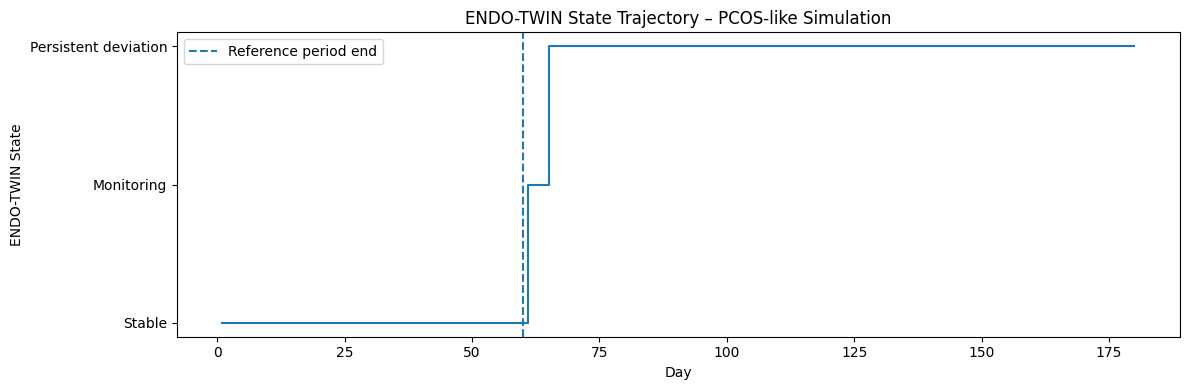


--- 8.8 State Transition Summary ---

 U001


,day,endo_state
0,1,Stable
179,180,Monitoring



 U201


,day,endo_state
36000,1,Stable
36060,61,Monitoring
36064,65,Persistent deviation



 U301


,day,endo_state
54000,1,Stable
54096,97,Monitoring
54100,101,Persistent deviation
54104,105,Stable



--- 8.9 Final State Distribution ---


,count
endo_state,
Stable,299
Persistent deviation,100
Monitoring,1



SECTION 8 COMPLETE

ENDO-TWIN now converts numerical physiological deviations
into interpretable longitudinal physiological states.

Three states are used:

1. Stable
   - No meaningful deviation from the personal trajectory.

2. Monitoring
   - A notable deviation is present but persistence criteria
     have not yet been satisfied.

3. Persistent deviation
   - Physiological deviation has remained elevated over time.

These states describe physiological patterns rather than
diagnosing PCOS or any other medical condition.

The state engine provides an interpretable output layer
for the ENDO-TWIN framework.



In [19]:
# ============================================================
# 8. ENDO-TWIN STATE ENGINE
# ============================================================

print("=" * 60)
print("8. ENDO-TWIN STATE ENGINE")
print("=" * 60)


# ------------------------------------------------------------
# 8.1 DEFINE PHYSIOLOGICAL STATES
# ------------------------------------------------------------

print("\n--- 8.1 Defining ENDO-TWIN States ---")

def assign_state(row):

    if row["persistent_deviation"] == 1:
        return "Persistent deviation"

    elif row["deviation_score"] >= 2:
        return "Monitoring"

    else:
        return "Stable"


synthetic["endo_state"] = synthetic.apply(
    assign_state,
    axis=1
)

print("ENDO-TWIN states assigned successfully.")


# ------------------------------------------------------------
# 8.2 STATE DISTRIBUTION
# ------------------------------------------------------------

print("\n--- 8.2 Overall State Distribution ---")

state_distribution = (
    synthetic["endo_state"]
    .value_counts()
)

display(state_distribution)


# ------------------------------------------------------------
# 8.3 STATE DISTRIBUTION BY GROUP
# ------------------------------------------------------------

print("\n--- 8.3 State Distribution by Group ---")

state_by_group = pd.crosstab(
    synthetic["group"],
    synthetic["endo_state"],
    normalize="index"
).mul(100).round(2)

display(state_by_group)


# ------------------------------------------------------------
# 8.4 STATE COUNTS BY GROUP
# ------------------------------------------------------------

print("\n--- 8.4 State Counts by Group ---")

state_counts = pd.crosstab(
    synthetic["group"],
    synthetic["endo_state"]
)

display(state_counts)


# ------------------------------------------------------------
# 8.5 PCOS-LIKE USER STATE TRAJECTORY
# ------------------------------------------------------------

print("\n--- 8.5 PCOS-like User State Trajectory ---")

pcos_user = synthetic[
    synthetic["user_id"] == "U201"
]

display(
    pcos_user[
        pcos_user["day"].between(55, 75)
    ][
        [
            "day",
            "deviation_score",
            "rolling_deviation",
            "recent_significant_days",
            "persistent_deviation",
            "endo_state"
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 8.6 TEMPORARY DISTURBANCE STATE TRAJECTORY
# ------------------------------------------------------------

print("\n--- 8.6 Temporary Disturbance State Trajectory ---")

temporary_user = synthetic[
    synthetic["user_id"] == "U301"
]

display(
    temporary_user[
        temporary_user["day"].between(90, 110)
    ][
        [
            "day",
            "deviation_score",
            "rolling_deviation",
            "recent_significant_days",
            "persistent_deviation",
            "endo_state"
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 8.7 VISUALIZE PCOS-LIKE STATE
# ------------------------------------------------------------

print("\n--- 8.7 PCOS-like State Visualization ---")

state_numeric = {
    "Stable": 0,
    "Monitoring": 1,
    "Persistent deviation": 2
}

pcos_plot = pcos_user.copy()

pcos_plot["state_numeric"] = (
    pcos_plot["endo_state"].map(state_numeric)
)

plt.figure(figsize=(12, 4))

plt.step(
    pcos_plot["day"],
    pcos_plot["state_numeric"],
    where="post"
)

plt.yticks(
    [0, 1, 2],
    ["Stable", "Monitoring", "Persistent deviation"]
)

plt.axvline(
    60,
    linestyle="--",
    label="Reference period end"
)

plt.title(
    "ENDO-TWIN State Trajectory – PCOS-like Simulation"
)

plt.xlabel("Day")
plt.ylabel("ENDO-TWIN State")

plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8.8 COMPARE STATE TRANSITIONS
# ------------------------------------------------------------

print("\n--- 8.8 State Transition Summary ---")

for user in ["U001", "U201", "U301"]:

    user_data = synthetic[
        synthetic["user_id"] == user
    ]

    transitions = (
        user_data["endo_state"]
        .ne(user_data["endo_state"].shift())
    )

    transition_days = user_data.loc[
        transitions,
        ["day", "endo_state"]
    ]

    print("\n", user)
    display(transition_days)


# ------------------------------------------------------------
# 8.9 FINAL STATE FOR EACH USER
# ------------------------------------------------------------

print("\n--- 8.9 Final State Distribution ---")

final_state = (
    synthetic
    .sort_values("day")
    .groupby("user_id")
    .tail(1)
)

final_state_distribution = (
    final_state["endo_state"]
    .value_counts()
)

display(final_state_distribution)


# ------------------------------------------------------------
# 8.10 SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SECTION 8 COMPLETE")
print("=" * 60)

print("""
ENDO-TWIN now converts numerical physiological deviations
into interpretable longitudinal physiological states.

Three states are used:

1. Stable
   - No meaningful deviation from the personal trajectory.

2. Monitoring
   - A notable deviation is present but persistence criteria
     have not yet been satisfied.

3. Persistent deviation
   - Physiological deviation has remained elevated over time.

These states describe physiological patterns rather than
diagnosing PCOS or any other medical condition.

The state engine provides an interpretable output layer
for the ENDO-TWIN framework.
""")

**9. SYNTHETIC VALIDATION**

In [20]:
# ============================================================
# 9. SYNTHETIC VALIDATION
# ============================================================

print("=" * 60)
print("9. SYNTHETIC VALIDATION")
print("=" * 60)

# ------------------------------------------------------------
# 9.1 FINAL STATE FOR EACH USER
# ------------------------------------------------------------

print("\n--- 9.1 Final State for Each User ---")

final_state = (
    synthetic
    .sort_values(["user_id", "day"])
    .groupby("user_id")
    .tail(1)
    [["user_id", "group", "endo_state"]]
    .copy()
)

print("Number of users:", len(final_state))

display(
    final_state["endo_state"]
    .value_counts()
    .rename("count")
)

9. SYNTHETIC VALIDATION

--- 9.1 Final State for Each User ---
Number of users: 400


,count
endo_state,
Stable,299
Persistent deviation,100
Monitoring,1


In [21]:
# ------------------------------------------------------------
# 9.2 EXPECTED VS ACTUAL FINAL STATE
# ------------------------------------------------------------

print("\n--- 9.2 Expected vs Actual Final State ---")

# Expected final state in the synthetic experiment
final_state["expected_state"] = np.where(
    final_state["group"] == "pcos_like",
    "Persistent deviation",
    "Stable"
)

final_state["correct"] = (
    final_state["endo_state"] == final_state["expected_state"]
)

validation_accuracy = final_state["correct"].mean() * 100

print(f"Final-state validation accuracy: {validation_accuracy:.2f}%")

display(
    final_state[
        ["group", "expected_state", "endo_state", "correct"]
    ].head(20)
)


--- 9.2 Expected vs Actual Final State ---
Final-state validation accuracy: 99.75%


,group,expected_state,endo_state,correct
179,normal,Stable,Monitoring,False
359,normal,Stable,Stable,True
539,normal,Stable,Stable,True
719,normal,Stable,Stable,True
899,normal,Stable,Stable,True
1079,normal,Stable,Stable,True
1259,normal,Stable,Stable,True
1439,normal,Stable,Stable,True
1619,normal,Stable,Stable,True
1799,normal,Stable,Stable,True


In [22]:
# ------------------------------------------------------------
# 9.3 GROUP-WISE VALIDATION
# ------------------------------------------------------------

print("\n--- 9.3 Group-wise Validation ---")

group_validation = (
    final_state
    .groupby("group")
    .agg(
        users=("user_id", "count"),
        correct=("correct", "sum")
    )
)

group_validation["accuracy_percent"] = (
    group_validation["correct"]
    / group_validation["users"]
    * 100
)

display(group_validation.round(2))


--- 9.3 Group-wise Validation ---


,users,correct,accuracy_percent
group,,,
normal,100,99,99.0
pcos_like,100,100,100.0
temporary_disturbance,100,100,100.0
variable,100,100,100.0



--- 9.4 Final-State Confusion Matrix ---
Rows = Actual synthetic condition
Columns = ENDO-TWIN final state

Confusion Matrix:
[[300   0]
 [  0 100]]


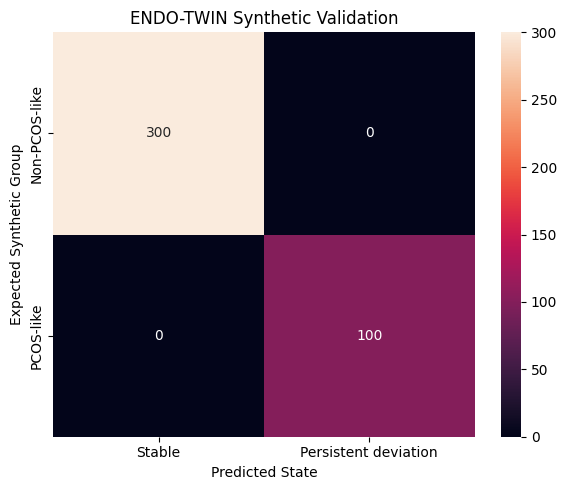

In [23]:
# ------------------------------------------------------------
# 9.4 CONFUSION MATRIX
# ------------------------------------------------------------

print("\n--- 9.4 Final-State Confusion Matrix ---")

actual = (
    final_state["group"] == "pcos_like"
).astype(int)

predicted = (
    final_state["endo_state"] == "Persistent deviation"
).astype(int)

cm = confusion_matrix(actual, predicted)

print("Rows = Actual synthetic condition")
print("Columns = ENDO-TWIN final state")
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Stable", "Persistent deviation"],
    yticklabels=["Non-PCOS-like", "PCOS-like"]
)

plt.title("ENDO-TWIN Synthetic Validation")
plt.xlabel("Predicted State")
plt.ylabel("Expected Synthetic Group")
plt.tight_layout()
plt.show()

In [24]:
# ------------------------------------------------------------
# 9.5 SYNTHETIC DETECTION METRICS
# ------------------------------------------------------------

print("\n--- 9.5 Synthetic Detection Metrics ---")

accuracy = accuracy_score(actual, predicted)
precision = precision_score(actual, predicted, zero_division=0)
recall = recall_score(actual, predicted, zero_division=0)
f1 = f1_score(actual, predicted, zero_division=0)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")


--- 9.5 Synthetic Detection Metrics ---
Accuracy : 100.00%
Precision: 100.00%
Recall   : 100.00%
F1 Score : 100.00%



--- 9.6 Final State Distribution by Group ---


endo_state,Monitoring,Persistent deviation,Stable
group,,,
normal,1.0,0.0,99.0
pcos_like,0.0,100.0,0.0
temporary_disturbance,0.0,0.0,100.0
variable,0.0,0.0,100.0


<Figure size 900x500 with 0 Axes>

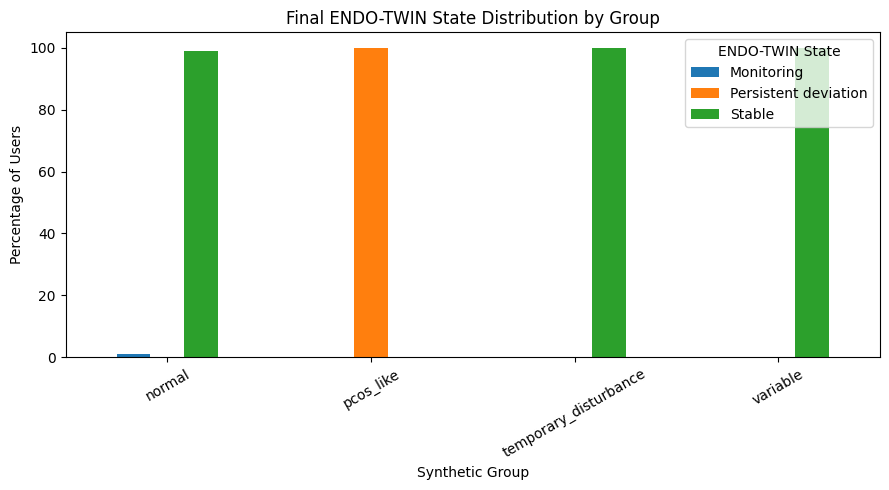


--- 9.7 Temporary Disturbance Recovery ---
Temporary disturbance users ending in Stable state: 100.00%

This checks whether short-term physiological disturbances are eventually distinguished from persistent trajectories.

SYNTHETIC VALIDATION SUMMARY
PCOS-like users ending in Persistent deviation: 100.00%
Non-PCOS-like users ending in Stable: 99.67%
Overall final-state validation accuracy: 99.75%

The synthetic validation evaluates whether ENDO-TWIN behaves
according to the patterns intentionally encoded in the simulation.

A persistent PCOS-like trajectory should remain in the
Persistent deviation state, while normal, variable, and
temporary disturbance trajectories should return to or remain
in the Stable state by the end of observation.

These results validate the internal behaviour of the synthetic
framework and should not be interpreted as clinical validation.



In [25]:
# ------------------------------------------------------------
# 9.6 FINAL STATE DISTRIBUTION BY GROUP
# ------------------------------------------------------------

print("\n--- 9.6 Final State Distribution by Group ---")

final_state_distribution = pd.crosstab(
    final_state["group"],
    final_state["endo_state"],
    normalize="index"
) * 100

display(
    final_state_distribution.round(2)
)

plt.figure(figsize=(9, 5))

final_state_distribution.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Final ENDO-TWIN State Distribution by Group")
plt.xlabel("Synthetic Group")
plt.ylabel("Percentage of Users")
plt.xticks(rotation=30)
plt.legend(title="ENDO-TWIN State")
plt.tight_layout()
plt.show()
# ------------------------------------------------------------
# 9.7 TEMPORARY DISTURBANCE RECOVERY
# ------------------------------------------------------------

print("\n--- 9.7 Temporary Disturbance Recovery ---")

temporary_final = final_state[
    final_state["group"] == "temporary_disturbance"
]

temporary_stable_rate = (
    (temporary_final["endo_state"] == "Stable").mean() * 100
)

print(
    f"Temporary disturbance users ending in Stable state: "
    f"{temporary_stable_rate:.2f}%"
)

print(
    "\nThis checks whether short-term physiological disturbances "
    "are eventually distinguished from persistent trajectories."
)
# ------------------------------------------------------------
# 9.8 VALIDATION SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SYNTHETIC VALIDATION SUMMARY")
print("=" * 60)

pcos_final_persistent = (
    final_state[
        final_state["group"] == "pcos_like"
    ]["endo_state"]
    .eq("Persistent deviation")
    .mean() * 100
)

non_pcos_final_stable = (
    final_state[
        final_state["group"] != "pcos_like"
    ]["endo_state"]
    .eq("Stable")
    .mean() * 100
)

print(
    f"PCOS-like users ending in Persistent deviation: "
    f"{pcos_final_persistent:.2f}%"
)

print(
    f"Non-PCOS-like users ending in Stable: "
    f"{non_pcos_final_stable:.2f}%"
)

print(
    f"Overall final-state validation accuracy: "
    f"{validation_accuracy:.2f}%"
)

print("""
The synthetic validation evaluates whether ENDO-TWIN behaves
according to the patterns intentionally encoded in the simulation.

A persistent PCOS-like trajectory should remain in the
Persistent deviation state, while normal, variable, and
temporary disturbance trajectories should return to or remain
in the Stable state by the end of observation.

These results validate the internal behaviour of the synthetic
framework and should not be interpreted as clinical validation.
""")


**10. MCPHASES DATASET**

In [26]:
# ============================================================
# 10. REAL mcPHASES DATASET
# ============================================================

print("=" * 60)
print("10. REAL mcPHASES DATASET")
print("=" * 60)

print("\n--- 10.1 Dataset Sizes ---")

datasets = {
    "Subject information": subject_info,
    "Hormones and self-report": hormones,
    "Resting heart rate": resting_hr,
    "Sleep score": sleep_score,
    "HRV": hrv,
    "Temperature": temperature
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

10. REAL mcPHASES DATASET

--- 10.1 Dataset Sizes ---
Subject information: (42, 8)
Hormones and self-report: (5659, 22)
Resting heart rate: ()
Sleep score: (5308, 12)
HRV: ()
Temperature: ()


In [27]:
# ------------------------------------------------------------
# 10.2 PARTICIPANT COVERAGE
# ------------------------------------------------------------

print("\n--- 10.2 Participant Coverage ---")

for name, df in datasets.items():
    if isinstance(df, pd.DataFrame) and "id" in df.columns:
        print(
            f"{name}: "
            f"{df['id'].nunique()} participants"
        )


--- 10.2 Participant Coverage ---
Subject information: 42 participants
Hormones and self-report: 42 participants
Sleep score: 42 participants


In [28]:
import pandas as pd

# ------------------------------------------------------------
# Restore overwritten DataFrames from the saved CSVs
# ------------------------------------------------------------
resting_hr = pd.read_csv("resting_heart_rate.csv")
hrv = pd.read_csv("hrv_data/heart_rate_variability_details.csv.download/heart_rate_variability_details.csv")
temperature = pd.read_csv("temperature_data/wrist_temperature.csv.download/wrist_temperature.csv")

# Re-establish the datasets dictionary with the restored DataFrames
datasets = {
    "Subject information": subject_info,
    "Hormones and self-report": hormones,
    "Resting heart rate": resting_hr,
    "Sleep score": sleep_score,
    "HRV": hrv,
    "Temperature": temperature
}

# ------------------------------------------------------------
# 10.3 STUDY-DAY COVERAGE
# ------------------------------------------------------------

print("\n--- 10.3 Study-day Coverage ---")

for name, df in datasets.items():
    if isinstance(df, pd.DataFrame) and "day_in_study" in df.columns:
        print(
            f"{name}: "
            f"{df['day_in_study'].min()} - "
            f"{df['day_in_study'].max()}"
        )


--- 10.3 Study-day Coverage ---
Hormones and self-report: 1 - 1004
Resting heart rate: 1 - 1004
Sleep score: 1 - 1004
HRV: 1 - 1004
Temperature: 3.0 - 69.0


In [29]:
# ------------------------------------------------------------
# 10.4 DAILY HRV AGGREGATION
# ------------------------------------------------------------

print("\n--- 10.4 Daily HRV Aggregation ---")

daily_hrv = (
    hrv
    .groupby(["id", "day_in_study"], as_index=False)
    .agg(
        hrv_rmssd=("rmssd", "median"),
        hrv_coverage=("coverage", "mean")
    )
)

print("Daily HRV shape:", daily_hrv.shape)

display(daily_hrv.head())


--- 10.4 Daily HRV Aggregation ---
Daily HRV shape: (559, 4)


,id,day_in_study,hrv_rmssd,hrv_coverage
0,2,7,41.0790,0.936000
1,2,8,44.6445,0.966779
2,2,9,46.3810,0.970962
3,2,10,44.0465,0.973565
4,2,11,40.6970,0.967821


In [30]:
# ------------------------------------------------------------
# 10.5 DAILY TEMPERATURE AGGREGATION
# ------------------------------------------------------------

print("\n--- 10.5 Daily Temperature Aggregation ---")

daily_temperature = (
    temperature
    .groupby(["id", "day_in_study"], as_index=False)
    .agg(
        temperature_diff=("temperature_diff_from_baseline", "median")
    )
)

print(
    "Daily temperature shape:",
    daily_temperature.shape
)

display(daily_temperature.head())


--- 10.5 Daily Temperature Aggregation ---
Daily temperature shape: (33, 3)


,id,day_in_study,temperature_diff
0,1,3.0,-2.278587
1,1,4.0,-1.430572
2,1,6.0,-0.385697
3,1,7.0,-0.636627
4,1,9.0,-0.285056


In [31]:
# ------------------------------------------------------------
# 10.6 DAILY PHYSIOLOGICAL DATASET
# ------------------------------------------------------------

print("\n--- 10.6 Creating Daily Physiological Dataset ---")

real_physiology = resting_hr[
    ["id", "day_in_study", "value"]
].rename(
    columns={"value": "resting_hr"}
)

# Add sleep information
sleep_daily = (
    sleep_score
    .groupby(["id", "day_in_study"], as_index=False)
    .agg(
        sleep_score=("overall_score", "mean"),
        deep_sleep_minutes=("deep_sleep_in_minutes", "mean"),
        sleep_resting_hr=("resting_heart_rate", "mean"),
        restlessness=("restlessness", "mean")
    )
)

real_physiology = real_physiology.merge(
    sleep_daily,
    on=["id", "day_in_study"],
    how="left"
)

# Add daily HRV
real_physiology = real_physiology.merge(
    daily_hrv,
    on=["id", "day_in_study"],
    how="left"
)

# Add daily temperature
real_physiology = real_physiology.merge(
    daily_temperature,
    on=["id", "day_in_study"],
    how="left"
)

print("Real physiological dataset shape:")
print(real_physiology.shape)

display(real_physiology.head())


--- 10.6 Creating Daily Physiological Dataset ---
Real physiological dataset shape:
(13737, 10)


,id,day_in_study,resting_hr,sleep_score,deep_sleep_minutes,sleep_resting_hr,restlessness,hrv_rmssd,hrv_coverage,temperature_diff
0,1,1,74.785346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,80.407307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,84.686869,NaN,NaN,NaN,NaN,NaN,NaN,-2.278587
3,1,4,83.852219,80.0,93.0,84.0,0.056404,NaN,NaN,-1.430572
4,1,5,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# ------------------------------------------------------------
# 10.7 HORMONE / CYCLE VALIDATION DATA
# ------------------------------------------------------------

print("\n--- 10.7 Hormone and Cycle Validation Data ---")

real_hormone_validation = hormones[
    [
        "id",
        "day_in_study",
        "phase",
        "lh",
        "estrogen",
        "pdg"
    ]
].copy()

print(
    "Hormone validation dataset shape:",
    real_hormone_validation.shape
)

display(real_hormone_validation.head())


--- 10.7 Hormone and Cycle Validation Data ---
Hormone validation dataset shape: (5659, 6)


,id,day_in_study,phase,lh,estrogen,pdg
0,1,1,Follicular,2.9,94.2,NaN
1,1,2,Follicular,1.2,226.3,NaN
2,1,3,Follicular,3.5,276.8,NaN
3,1,4,Fertility,1.8,322.1,NaN
4,1,5,Fertility,4.6,244.9,NaN


In [33]:
# ------------------------------------------------------------
# 10.8 OVERLAPPING PARTICIPANT-DAYS
# ------------------------------------------------------------

print("\n--- 10.8 Overlapping Participant-Days ---")

physiology_keys = real_physiology[
    ["id", "day_in_study"]
].drop_duplicates()

hormone_keys = real_hormone_validation[
    ["id", "day_in_study"]
].drop_duplicates()

overlap = physiology_keys.merge(
    hormone_keys,
    on=["id", "day_in_study"],
    how="inner"
)

print(
    "Participant-days with both physiological and "
    "hormone/cycle information:",
    len(overlap)
)

print(
    "Participants represented in overlap:",
    overlap["id"].nunique()
)


--- 10.8 Overlapping Participant-Days ---
Participant-days with both physiological and hormone/cycle information: 5659
Participants represented in overlap: 42


In [34]:
# ------------------------------------------------------------
# 10.9 REAL DATA SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("REAL mcPHASES DATA SUMMARY")
print("=" * 60)

print(
    f"""
The real mcPHASES dataset contains longitudinal physiological
measurements from multiple participants.

High-frequency HRV and wrist-temperature measurements were
aggregated to the participant-day level so that they can be
aligned with other daily physiological measurements.

Resting heart rate, sleep-related measurements, HRV and
temperature are retained as physiological variables.

Hormone measurements and menstrual-cycle phase are kept
separate and will be used only for physiological validation.

This separation prevents the model from directly using hormone
measurements as inputs when evaluating wearable-derived
physiological patterns.
"""
)


REAL mcPHASES DATA SUMMARY

The real mcPHASES dataset contains longitudinal physiological
measurements from multiple participants.

High-frequency HRV and wrist-temperature measurements were
aggregated to the participant-day level so that they can be
aligned with other daily physiological measurements.

Resting heart rate, sleep-related measurements, HRV and
temperature are retained as physiological variables.

Hormone measurements and menstrual-cycle phase are kept
separate and will be used only for physiological validation.

This separation prevents the model from directly using hormone
measurements as inputs when evaluating wearable-derived
physiological patterns.



**11. REAL-DATA PHYSIOLOGICAL VALIDATION**

In [35]:
# ============================================================
# 11. REAL-DATA PHYSIOLOGICAL VALIDATION
# ============================================================

print("=" * 60)
print("11. REAL-DATA PHYSIOLOGICAL VALIDATION")
print("=" * 60)

# Copy datasets so original data remain unchanged
real_validation = real_physiology.copy()
hormone_validation = real_hormone_validation.copy()

# Remove invalid resting HR values
real_validation.loc[
    real_validation["resting_hr"] <= 0, "resting_hr"
] = np.nan

# Merge physiological data with hormone/cycle information
validation_data = pd.merge(
    real_validation,
    hormone_validation,
    on=["id", "day_in_study"],
    how="inner"
)

print("\n--- 11.1 Validation Dataset ---")
print("Shape:", validation_data.shape)
print("Participants:", validation_data["id"].nunique())

display(validation_data.head())

11. REAL-DATA PHYSIOLOGICAL VALIDATION

--- 11.1 Validation Dataset ---
Shape: (13737, 14)
Participants: 42


,id,day_in_study,resting_hr,sleep_score,deep_sleep_minutes,sleep_resting_hr,restlessness,hrv_rmssd,hrv_coverage,temperature_diff,phase,lh,estrogen,pdg
0,1,1,74.785346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Follicular,2.9,94.2,NaN
1,1,2,80.407307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Follicular,1.2,226.3,NaN
2,1,3,84.686869,NaN,NaN,NaN,NaN,NaN,NaN,-2.278587,Follicular,3.5,276.8,NaN
3,1,4,83.852219,80.0,93.0,84.0,0.056404,NaN,NaN,-1.430572,Fertility,1.8,322.1,NaN
4,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fertility,4.6,244.9,NaN


In [42]:

# Section 11 — Correct participant-day aggregation

real_validation = real_physiology.copy()

# Remove invalid resting heart-rate values
real_validation.loc[
    real_validation["resting_hr"] <= 0, "resting_hr"
] = np.nan

physiology_features = [
    "resting_hr",
    "sleep_score",
    "deep_sleep_minutes",
    "sleep_resting_hr",
    "restlessness",
    "hrv_rmssd",
    "hrv_coverage",
    "temperature_diff"
]

# Combine repeated records into one row per participant-day
real_daily = (
    real_validation
    .groupby(["id", "day_in_study"], as_index=False)[physiology_features]
    .median()
)

# Keep hormone measurements separate for validation
hormone_validation = real_hormone_validation.copy()

validation_data = real_daily.merge(
    hormone_validation,
    on=["id", "day_in_study"],
    how="inner"
)

print("Validation dataset shape:", validation_data.shape)
print("Participants:", validation_data["id"].nunique())
print(
    "Duplicate participant-days:",
    validation_data.duplicated(["id", "day_in_study"]).sum()
)

display(validation_data.head())

Validation dataset shape: (5659, 14)
Participants: 42
Duplicate participant-days: 0


,id,day_in_study,resting_hr,sleep_score,deep_sleep_minutes,sleep_resting_hr,restlessness,hrv_rmssd,hrv_coverage,temperature_diff,phase,lh,estrogen,pdg
0,1,1,74.785346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Follicular,2.9,94.2,NaN
1,1,2,80.407307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Follicular,1.2,226.3,NaN
2,1,3,84.686869,NaN,NaN,NaN,NaN,NaN,NaN,-2.278587,Follicular,3.5,276.8,NaN
3,1,4,83.852219,80.0,93.0,84.0,0.056404,NaN,NaN,-1.430572,Fertility,1.8,322.1,NaN
4,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fertility,4.6,244.9,NaN


In [43]:
print("\n--- 11.2 Missing Physiological Measurements ---")

validation_features = [
    "resting_hr",
    "sleep_score",
    "deep_sleep_minutes",
    "sleep_resting_hr",
    "restlessness",
    "hrv_rmssd",
    "temperature_diff"
]

missing_summary = validation_data[validation_features].isnull().sum()

display(
    pd.DataFrame({
        "missing_values": missing_summary,
        "available_values": validation_data[validation_features].notnull().sum()
    })
)


--- 11.2 Missing Physiological Measurements ---


,missing_values,available_values
resting_hr,787,4872
sleep_score,581,5078
deep_sleep_minutes,582,5077
sleep_resting_hr,581,5078
restlessness,581,5078
hrv_rmssd,5100,559
temperature_diff,5626,33



--- 11.3 Physiological Variables Across Cycle Phases ---


,resting_hr,sleep_score,deep_sleep_minutes,sleep_resting_hr,restlessness,hrv_rmssd,temperature_diff
phase,,,,,,,
Fertility,69.56,76.32,78.35,66.92,0.09,52.13,-1.21
Follicular,67.77,77.57,79.99,65.11,0.09,52.61,-0.54
Luteal,70.73,76.86,79.13,68.99,0.09,44.38,-0.31
Menstrual,68.92,77.67,76.87,67.33,0.09,54.25,-0.54


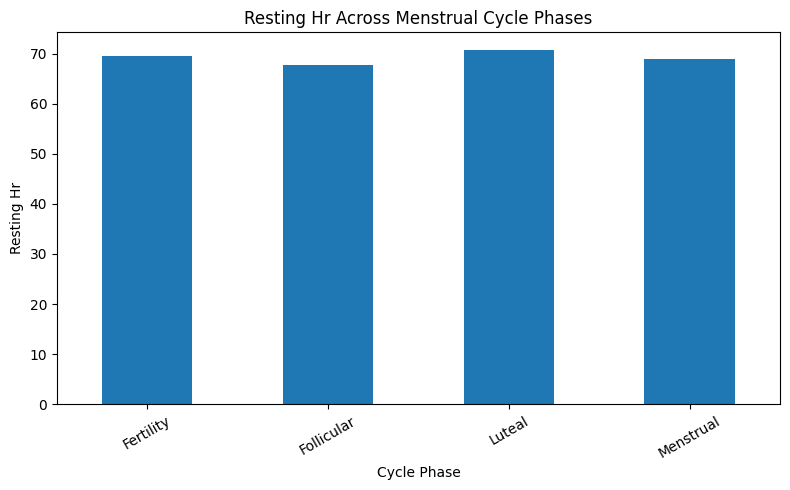

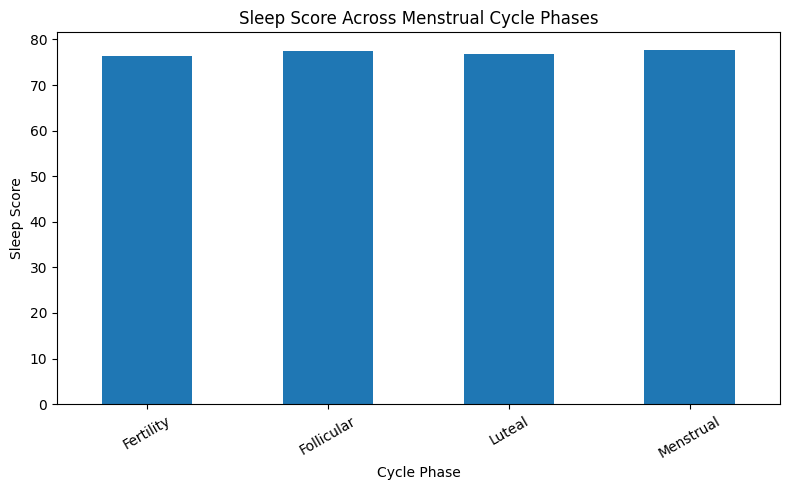

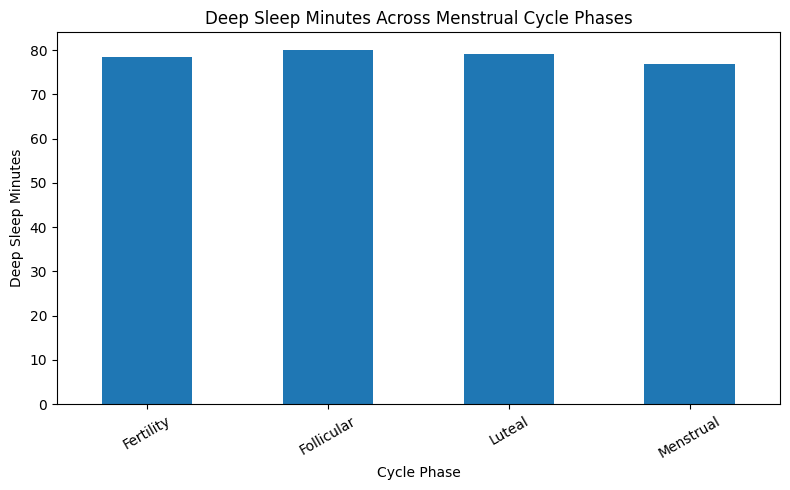

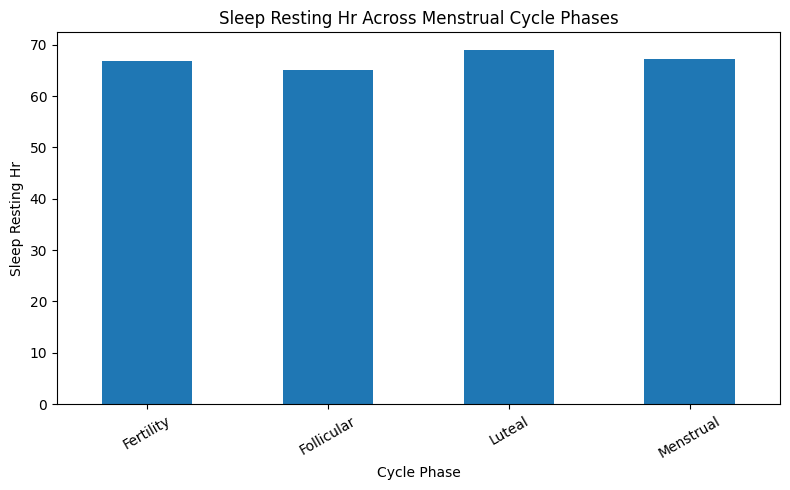

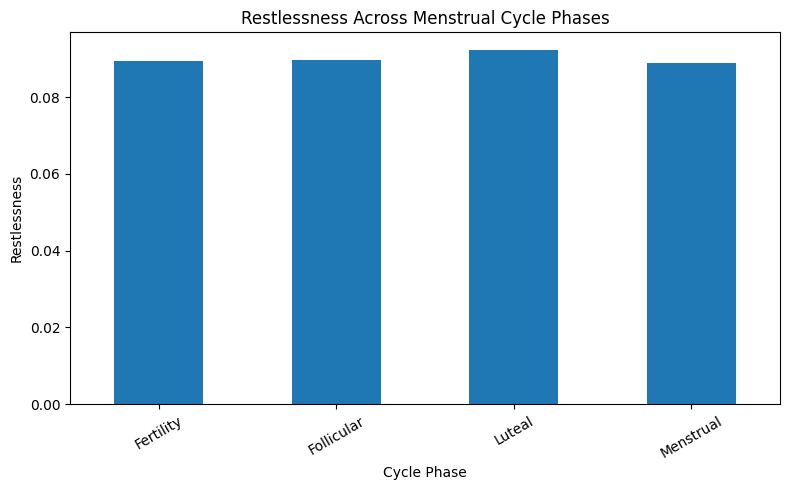

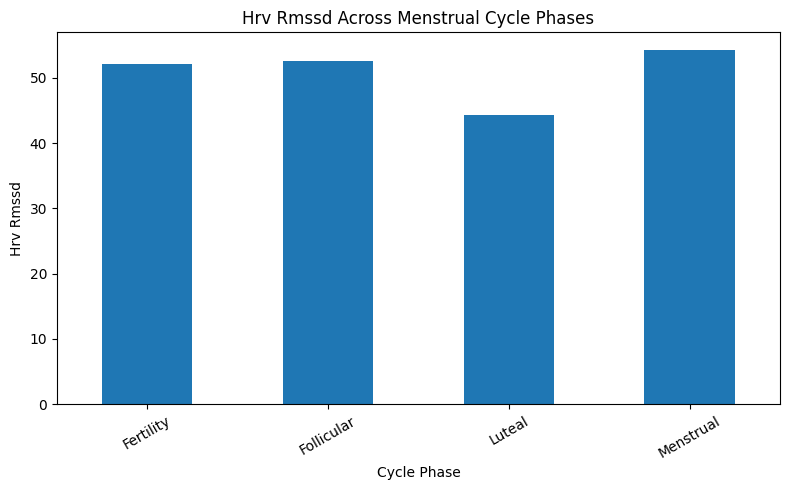

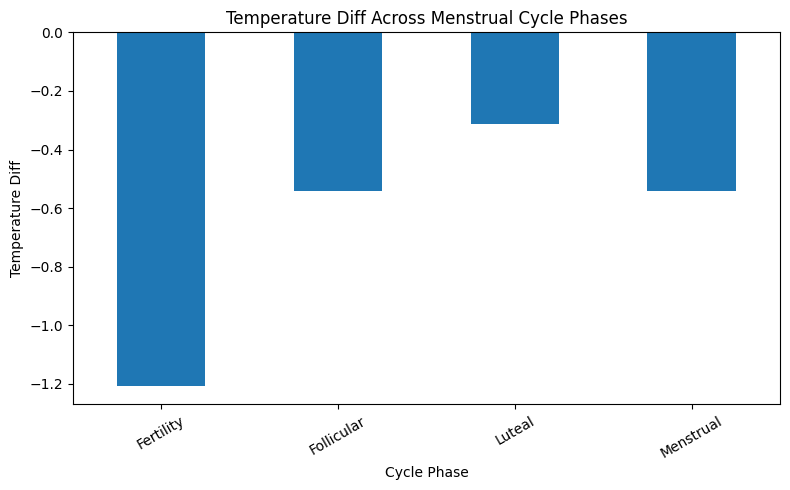

In [44]:
print("\n--- 11.3 Physiological Variables Across Cycle Phases ---")

phase_summary = validation_data.groupby("phase")[validation_features].mean()

display(phase_summary.round(2))
for feature in validation_features:

    phase_data = validation_data.groupby("phase")[feature].mean().dropna()

    if len(phase_data) > 1:
        plt.figure(figsize=(8, 5))
        phase_data.plot(kind="bar")
        plt.title(
            f"{feature.replace('_', ' ').title()} Across Menstrual Cycle Phases"
        )
        plt.xlabel("Cycle Phase")
        plt.ylabel(feature.replace("_", " ").title())
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

In [45]:
print("\n--- 11.4 Hormone–Physiology Correlations ---")

hormones_to_test = ["lh", "estrogen", "pdg"]

correlation_results = []

for hormone in hormones_to_test:

    for feature in validation_features:

        temp = validation_data[[hormone, feature]].dropna()

        if len(temp) >= 10:
            correlation, p_value = stats.spearmanr(
                temp[hormone],
                temp[feature]
            )

            correlation_results.append({
                "hormone": hormone,
                "physiological_feature": feature,
                "n": len(temp),
                "spearman_r": correlation,
                "p_value": p_value
            })

correlation_results = pd.DataFrame(correlation_results)

display(
    correlation_results.sort_values(
        "p_value"
    ).round(4)
)


--- 11.4 Hormone–Physiology Correlations ---


,hormone,physiological_feature,n,spearman_r,p_value
17,pdg,sleep_resting_hr,1757,0.1841,0.0000
3,lh,sleep_resting_hr,4864,-0.1093,0.0000
0,lh,resting_hr,4676,0.0700,0.0000
14,pdg,resting_hr,1863,0.0898,0.0001
10,estrogen,sleep_resting_hr,4863,0.0492,0.0006
9,estrogen,deep_sleep_minutes,4862,0.0470,0.0010
19,pdg,hrv_rmssd,100,-0.3198,0.0012
1,lh,sleep_score,4864,0.0451,0.0017
12,estrogen,hrv_rmssd,529,0.1280,0.0032
8,estrogen,sleep_score,4863,-0.0402,0.0050


In [46]:
print("\n--- 11.5 Strongest Observed Relationships ---")

strongest_relationships = (
    correlation_results
    .assign(abs_r=lambda x: x["spearman_r"].abs())
    .sort_values("abs_r", ascending=False)
    .head(10)
)

display(
    strongest_relationships[
        [
            "hormone",
            "physiological_feature",
            "n",
            "spearman_r",
            "p_value"
        ]
    ].round(4)
)


--- 11.5 Strongest Observed Relationships ---


,hormone,physiological_feature,n,spearman_r,p_value
13,estrogen,temperature_diff,33,-0.3500,0.0459
19,pdg,hrv_rmssd,100,-0.3198,0.0012
6,lh,temperature_diff,33,-0.2430,0.1729
17,pdg,sleep_resting_hr,1757,0.1841,0.0000
12,estrogen,hrv_rmssd,529,0.1280,0.0032
3,lh,sleep_resting_hr,4864,-0.1093,0.0000
14,pdg,resting_hr,1863,0.0898,0.0001
0,lh,resting_hr,4676,0.0700,0.0000
18,pdg,restlessness,1757,-0.0523,0.0283
10,estrogen,sleep_resting_hr,4863,0.0492,0.0006



--- 11.6 Hormone Patterns Across Cycle Phases ---


,lh,estrogen,pdg
phase,,,
Fertility,11.17,173.03,5.05
Follicular,5.65,101.68,3.54
Luteal,4.51,139.69,10.36
Menstrual,4.66,92.68,3.50


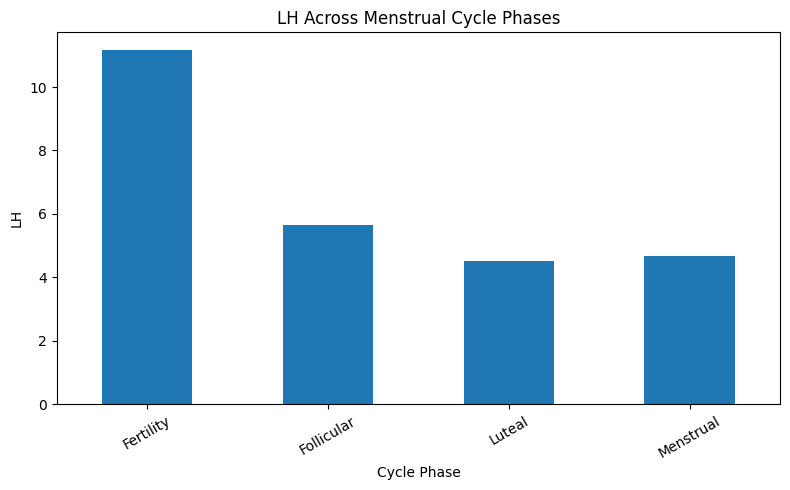

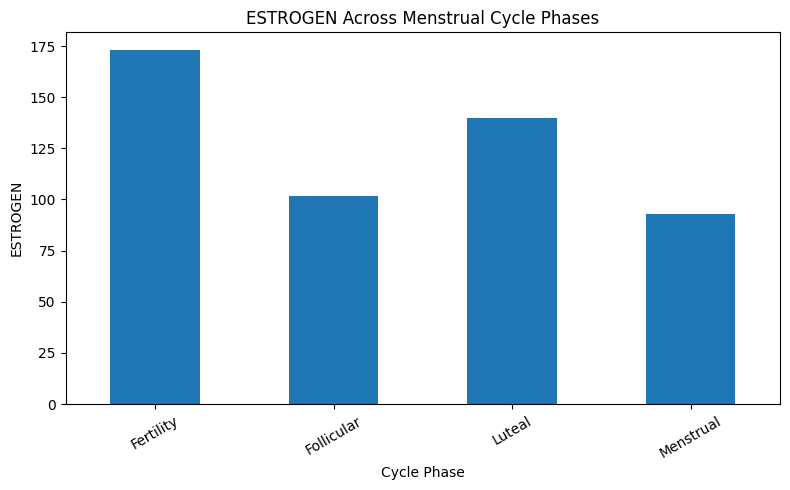

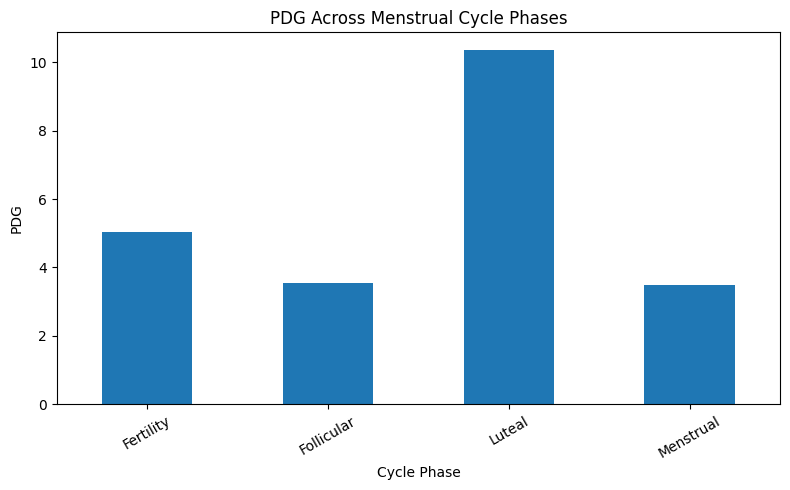

In [47]:
print("\n--- 11.6 Hormone Patterns Across Cycle Phases ---")

hormone_phase_summary = validation_data.groupby("phase")[
    ["lh", "estrogen", "pdg"]
].mean()

display(hormone_phase_summary.round(2))

for hormone in ["lh", "estrogen", "pdg"]:

    phase_data = (
        validation_data
        .groupby("phase")[hormone]
        .mean()
        .dropna()
    )

    if len(phase_data) > 1:
        plt.figure(figsize=(8, 5))
        phase_data.plot(kind="bar")
        plt.title(
            f"{hormone.upper()} Across Menstrual Cycle Phases"
        )
        plt.xlabel("Cycle Phase")
        plt.ylabel(hormone.upper())
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

In [48]:
print("\n" + "=" * 60)
print("REAL-DATA VALIDATION SUMMARY")
print("=" * 60)

print("""
The real mcPHASES dataset was used to examine whether
wearable-derived physiological variables show measurable
relationships with menstrual-cycle phase and hormone
measurements.

Hormone measurements were kept separate from the ENDO-TWIN
physiological input variables and were used only for validation.

Phase-wise physiological summaries and hormone–physiology
correlations were calculated using participant-day observations.

The results provide physiological grounding for the ENDO-TWIN
framework but do not establish clinical diagnostic performance.

Because HRV and temperature measurements have limited
participant-day coverage in the available dataset, conclusions
based on these variables should be interpreted cautiously.
""")


REAL-DATA VALIDATION SUMMARY

The real mcPHASES dataset was used to examine whether
wearable-derived physiological variables show measurable
relationships with menstrual-cycle phase and hormone
measurements.

Hormone measurements were kept separate from the ENDO-TWIN
physiological input variables and were used only for validation.

Phase-wise physiological summaries and hormone–physiology
correlations were calculated using participant-day observations.

The results provide physiological grounding for the ENDO-TWIN
framework but do not establish clinical diagnostic performance.

Because HRV and temperature measurements have limited
participant-day coverage in the available dataset, conclusions
based on these variables should be interpreted cautiously.



**12. MODEL COMPARISON**

In [49]:

# SECTION 12.1 — Personalized vs Population Baseline

from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

features = [
    "resting_hr",
    "hrv",
    "sleep_hours",
    "temperature",
    "activity"
]

# Keep only the required original columns
comparison_data = synthetic[
    ["user_id", "day", "group"] + features
].copy()

reference = comparison_data[comparison_data["day"] <= 60]
evaluation = comparison_data[comparison_data["day"] > 60].copy()

# 1. Each user's own baseline (days 1–60)
personal_stats = reference.groupby("user_id")[features].agg(
    ["mean", "std"]
)

personal_stats.columns = [
    f"{feature}_{stat}" for feature, stat in personal_stats.columns
]

evaluation = evaluation.merge(
    personal_stats, on="user_id", how="left"
)

personal_scores = []

for feature in features:
    baseline_mean = evaluation[f"{feature}_mean"]
    baseline_std = evaluation[f"{feature}_std"].replace(0, np.nan)

    z = (evaluation[feature] - baseline_mean) / baseline_std
    personal_scores.append(z.abs())

evaluation["personalized_score"] = (
    pd.concat(personal_scores, axis=1).mean(axis=1)
)

# 2. General population baseline (normal group, days 1–60)
normal_reference = reference[reference["group"] == "normal"]

population_mean = normal_reference[features].mean()
population_std = normal_reference[features].std().replace(0, np.nan)

population_scores = []

for feature in features:
    z = (
        evaluation[feature] - population_mean[feature]
    ) / population_std[feature]

    population_scores.append(z.abs())

evaluation["population_score"] = (
    pd.concat(population_scores, axis=1).mean(axis=1)
)

# Evaluate each user's average score after day 60
user_comparison = evaluation.groupby(
    ["user_id", "group"], as_index=False
).agg(
    personalized_score=("personalized_score", "mean"),
    population_score=("population_score", "mean")
)

user_comparison["pcos_like_label"] = (
    user_comparison["group"] == "pcos_like"
).astype(int)

# Compare ranking ability for distinguishing simulated PCOS-like
# users from all other simulated groups
y_true = user_comparison["pcos_like_label"]

results = []

for method in ["personalized_score", "population_score"]:
    auc = roc_auc_score(y_true, user_comparison[method])

    results.append({
        "method": method,
        "ROC_AUC": round(auc, 4)
    })

print("MODEL COMPARISON RESULTS")
display(pd.DataFrame(results))

print("\nMean score by synthetic group:")
display(
    user_comparison.groupby("group")[
        ["personalized_score", "population_score"]
    ].mean().round(3)
)

MODEL COMPARISON RESULTS


,method,ROC_AUC
0,personalized_score,1.0
1,population_score,1.0



Mean score by synthetic group:


,personalized_score,population_score
group,,
normal,0.818,0.839
pcos_like,3.143,2.720
temporary_disturbance,0.981,0.874
variable,0.817,1.002


In [50]:

# Compare PCOS-like and temporary-disturbance users directly

comparison_subset = user_comparison[
    user_comparison["group"].isin(
        ["pcos_like", "temporary_disturbance"]
    )
].copy()

y_true = (
    comparison_subset["group"] == "pcos_like"
).astype(int)

from sklearn.metrics import roc_auc_score

for method in ["personalized_score", "population_score"]:
    auc = roc_auc_score(y_true, comparison_subset[method])
    print(f"{method}: ROC-AUC = {auc:.3f}")

print("\nMean scores for these two groups:")
display(
    comparison_subset.groupby("group")[
        ["personalized_score", "population_score"]
    ].mean().round(3)
)

personalized_score: ROC-AUC = 1.000
population_score: ROC-AUC = 1.000

Mean scores for these two groups:


,personalized_score,population_score
group,,
pcos_like,3.143,2.720
temporary_disturbance,0.981,0.874


**13. EXPLAINABILITY**

In [52]:

# Find existing dataframes related to ENDO-TWIN

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if any(word in name.lower() for word in [
            "synthetic", "deviation", "persist", "state", "baseline"
        ]):
            print(f"\nDataFrame: {name}")
            print("Shape:", obj.shape)
            print("Columns:", obj.columns.tolist())


DataFrame: synthetic
Shape: (72000, 34)
Columns: ['user_id', 'day', 'resting_hr', 'hrv', 'sleep_hours', 'temperature', 'activity', 'group', 'resting_hr_baseline', 'hrv_baseline', 'sleep_hours_baseline', 'temperature_baseline', 'activity_baseline', 'resting_hr_std', 'hrv_std', 'sleep_hours_std', 'temperature_std', 'activity_std', 'hr_deviation', 'hrv_deviation', 'sleep_deviation', 'temperature_deviation', 'activity_deviation', 'hr_deviation_abs', 'hrv_deviation_abs', 'sleep_deviation_abs', 'temperature_deviation_abs', 'activity_deviation_abs', 'deviation_score', 'significant_deviation', 'rolling_deviation', 'recent_significant_days', 'persistent_deviation', 'endo_state']

DataFrame: personal_baseline
Shape: (400, 6)
Columns: ['user_id', 'resting_hr_baseline', 'hrv_baseline', 'sleep_hours_baseline', 'temperature_baseline', 'activity_baseline']

DataFrame: baseline_table
Shape: (400, 11)
Columns: ['user_id', 'resting_hr_baseline', 'hrv_baseline', 'sleep_hours_baseline', 'temperature_base

,Feature,Mean absolute deviation
0,Resting heart rate,1.275
3,Wrist temperature,1.268
2,Sleep duration,1.251
1,Heart rate variability,1.209
4,Physical activity,1.121


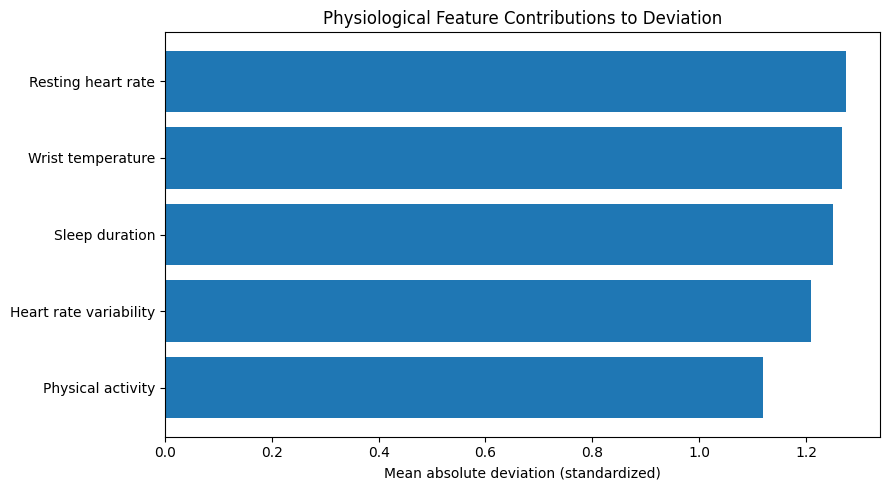

In [53]:

# SECTION 13.1 — Feature Contribution Analysis

deviation_columns = {
    "Resting heart rate": "hr_deviation_abs",
    "Heart rate variability": "hrv_deviation_abs",
    "Sleep duration": "sleep_deviation_abs",
    "Wrist temperature": "temperature_deviation_abs",
    "Physical activity": "activity_deviation_abs"
}

# Calculate mean absolute deviation for each feature
contribution = pd.DataFrame({
    "Feature": deviation_columns.keys(),
    "Mean absolute deviation": [
        synthetic[col].mean()
        for col in deviation_columns.values()
    ]
})

contribution = contribution.sort_values(
    "Mean absolute deviation", ascending=False
)

display(contribution.round(3))

# Visualize the results
plt.figure(figsize=(9, 5))
plt.barh(
    contribution["Feature"],
    contribution["Mean absolute deviation"]
)
plt.xlabel("Mean absolute deviation (standardized)")
plt.title("Physiological Feature Contributions to Deviation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

,Heart rate,HRV,Sleep,Temperature,Activity
group,,,,,
normal,0.810,0.810,0.815,0.809,0.804
pcos_like,2.527,2.315,2.462,2.519,1.979
temporary_disturbance,0.953,0.904,0.920,0.931,0.886
variable,0.809,0.805,0.808,0.813,0.814


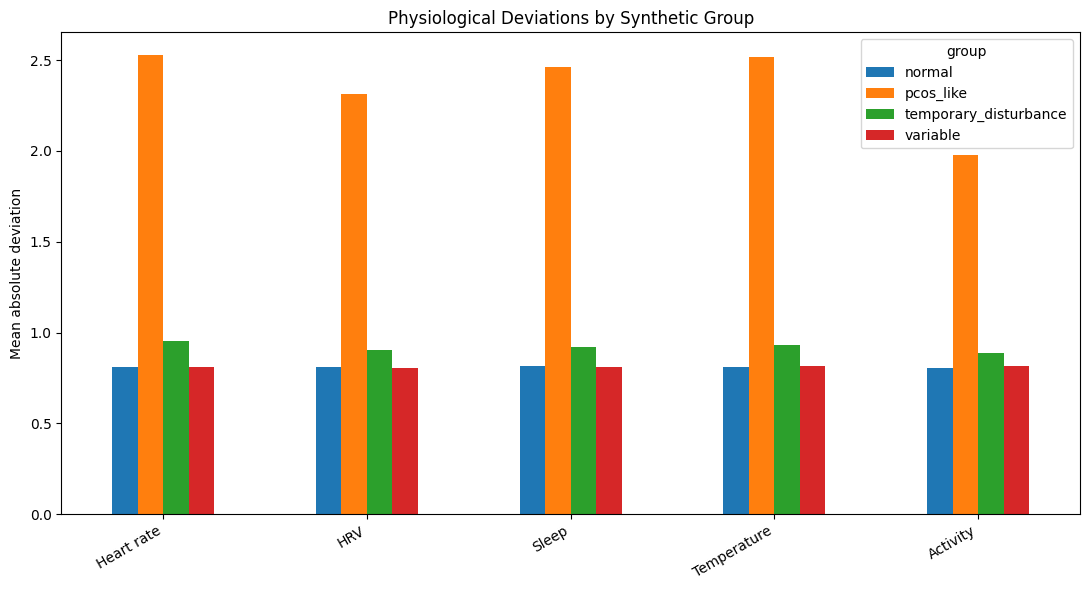

In [54]:

# SECTION 13.2 — Feature Deviations by Group

group_feature_analysis = synthetic.groupby("group")[
    [
        "hr_deviation_abs",
        "hrv_deviation_abs",
        "sleep_deviation_abs",
        "temperature_deviation_abs",
        "activity_deviation_abs"
    ]
].mean()

group_feature_analysis.columns = [
    "Heart rate",
    "HRV",
    "Sleep",
    "Temperature",
    "Activity"
]

display(group_feature_analysis.round(3))

group_feature_analysis.T.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Mean absolute deviation")
plt.title("Physiological Deviations by Synthetic Group")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**14. Visualization Dashboard**

In [55]:

# SECTION 14.1 — Dashboard Data Preparation

import pandas as pd
import matplotlib.pyplot as plt

# Check the dataset is ready
print("Dataset shape:", synthetic.shape)
print("Users:", synthetic["user_id"].nunique())
print("Study days:", synthetic["day"].min(), "to", synthetic["day"].max())
print("\nAvailable states:")
display(synthetic["endo_state"].value_counts().to_frame("Observations"))

print("\nGroup distribution:")
display(synthetic["group"].value_counts().to_frame("Users/rows"))

Dataset shape: (72000, 34)
Users: 400
Study days: 1 to 180

Available states:


,Observations
endo_state,
Stable,59189
Persistent deviation,11999
Monitoring,812



Group distribution:


,Users/rows
group,
normal,18000
variable,18000
pcos_like,18000
temporary_disturbance,18000


ENDO-TWIN USER DASHBOARD
------------------------
User ID: U001
Group: normal
Study period: 1 to 180

State distribution:


,Days
endo_state,
Stable,179
Monitoring,1



Final state: Monitoring


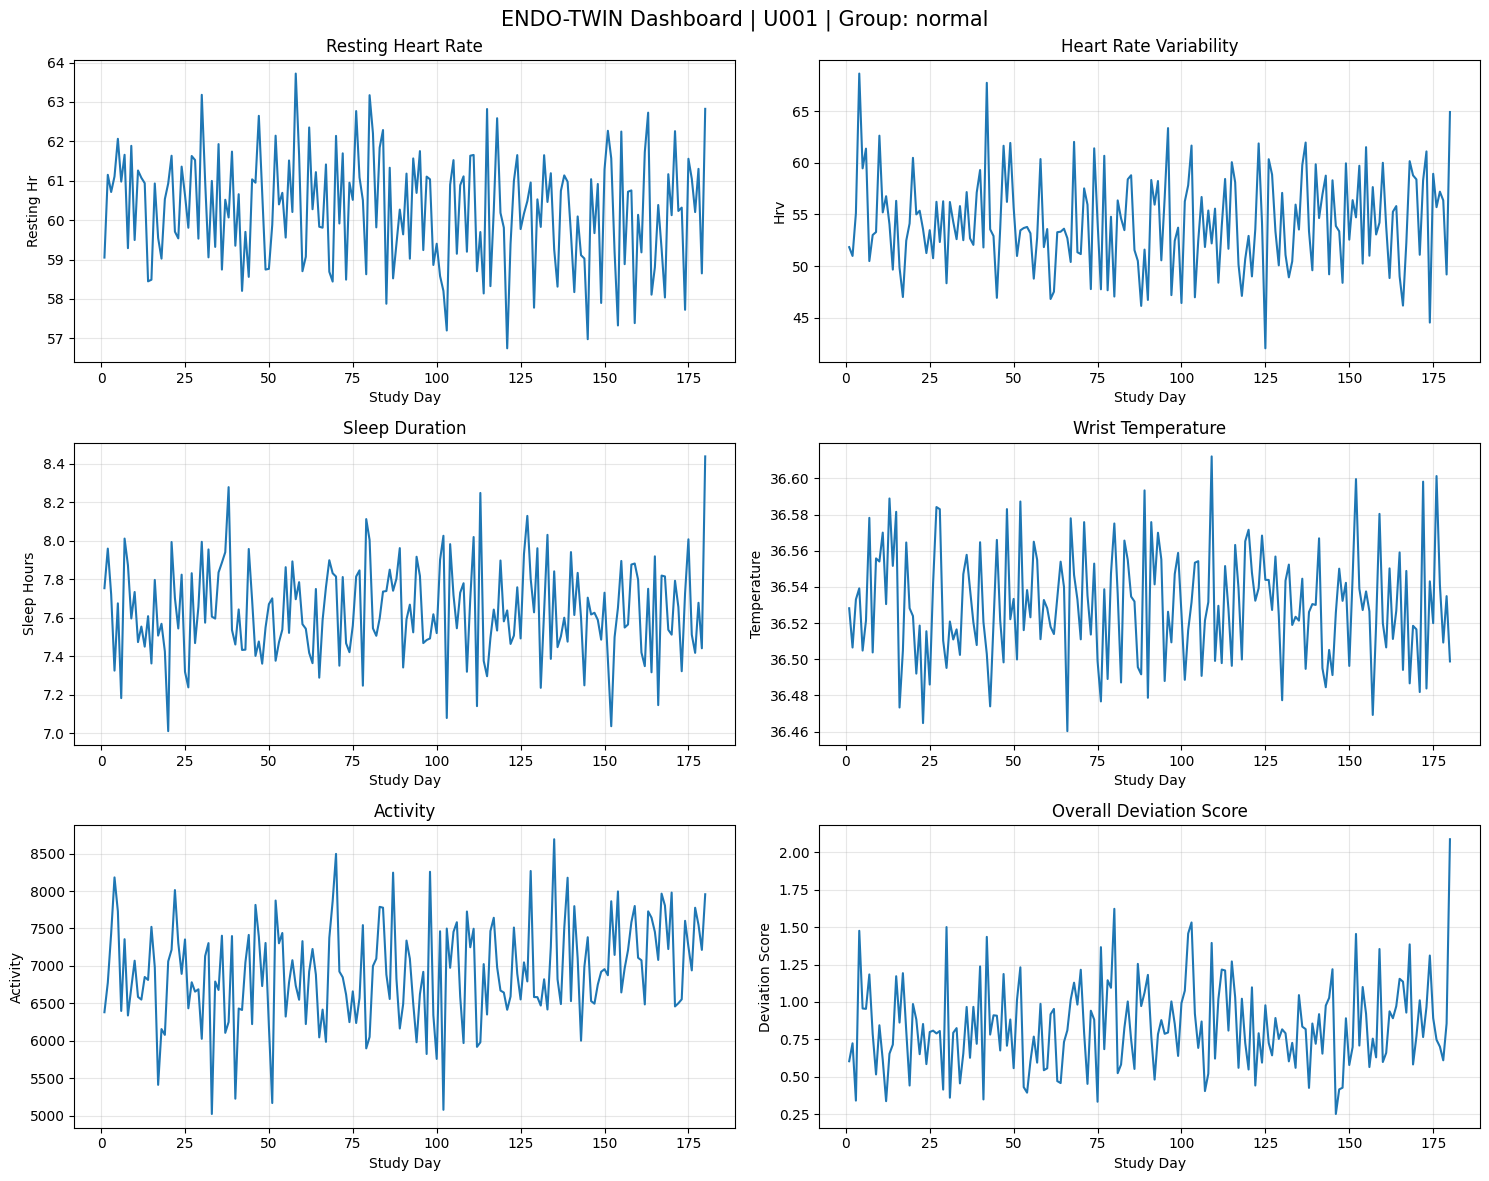

In [56]:
# SECTION 14.2 — Interactive User Dashboard

import matplotlib.pyplot as plt
import pandas as pd

# Select a user to view
user_list = sorted(synthetic["user_id"].unique())
selected_user = "U001"

user_data = synthetic[synthetic["user_id"] == selected_user].sort_values("day")

print("ENDO-TWIN USER DASHBOARD")
print("------------------------")
print("User ID:", selected_user)
print("Group:", user_data["group"].iloc[0])
print("Study period:", user_data["day"].min(), "to", user_data["day"].max())

print("\nState distribution:")
display(user_data["endo_state"].value_counts().to_frame("Days"))

print("\nFinal state:", user_data["endo_state"].iloc[-1])

# Plot physiological signals and deviation score
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle(
    f"ENDO-TWIN Dashboard | {selected_user} | "
    f"Group: {user_data['group'].iloc[0]}",
    fontsize=15
)

signals = [
    ("resting_hr", "Resting Heart Rate"),
    ("hrv", "Heart Rate Variability"),
    ("sleep_hours", "Sleep Duration"),
    ("temperature", "Wrist Temperature"),
    ("activity", "Activity"),
    ("deviation_score", "Overall Deviation Score")
]

for ax, (column, title) in zip(axes.flat, signals):
    ax.plot(user_data["day"], user_data[column])
    ax.set_title(title)
    ax.set_xlabel("Study Day")
    ax.set_ylabel(column.replace("_", " ").title())
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Dropdown(description='Select User:', index=14, layout=Layout(width='300px'), options=('U001', 'U002', 'U003', …

ENDO-TWIN USER DASHBOARD
------------------------
User ID: U015
Group: normal
Final state: Stable

State distribution:


,Days
endo_state,
Stable,180


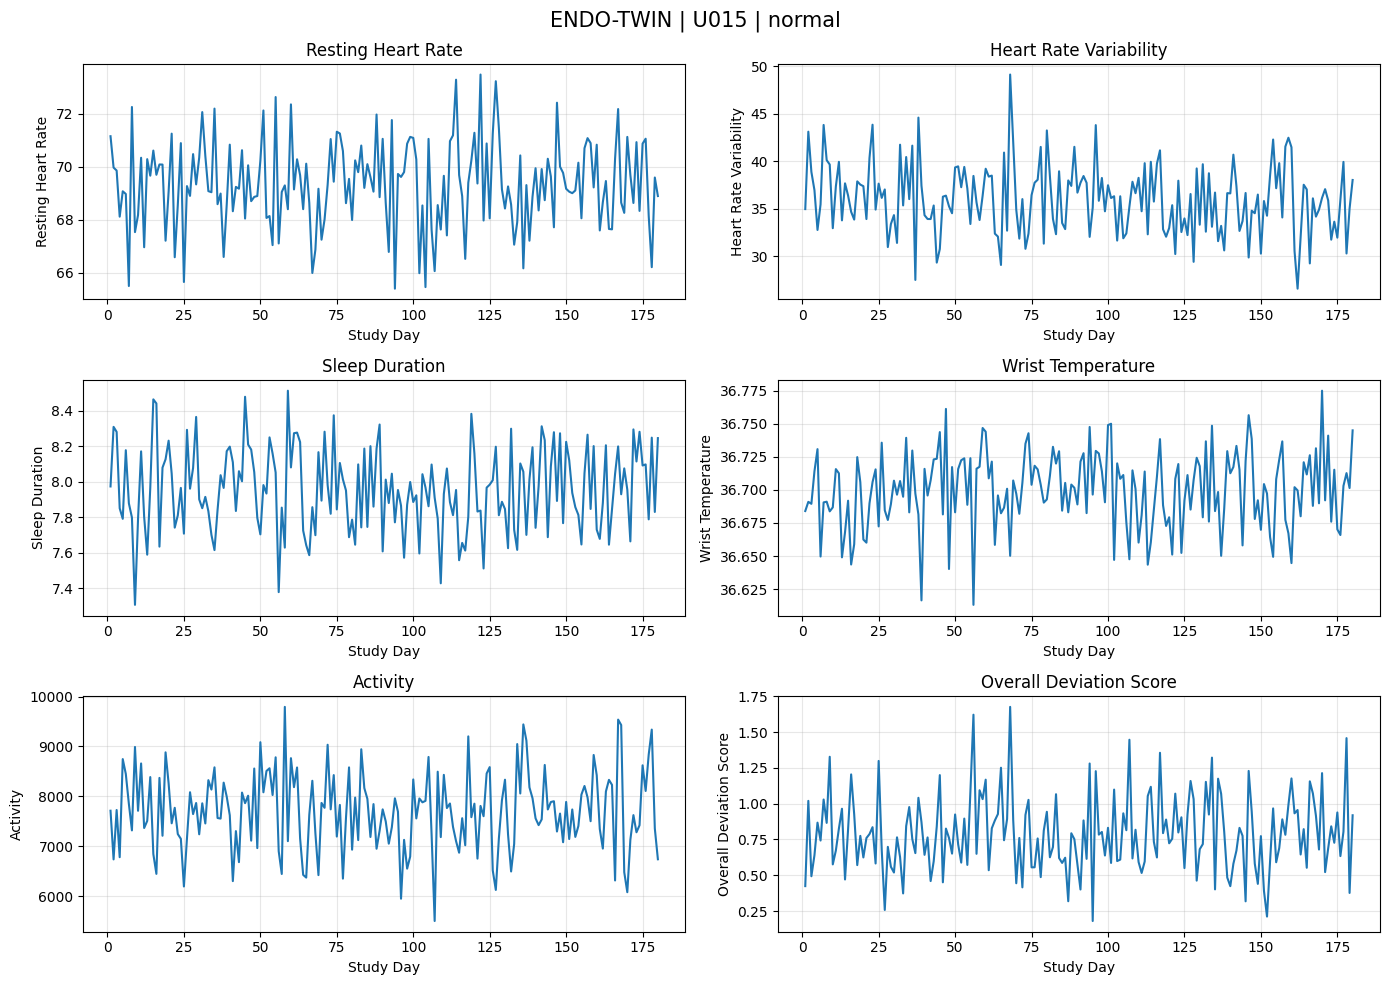

In [57]:
# SECTION 14.3 — Interactive ENDO-TWIN Dashboard

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

user_dropdown = widgets.Dropdown(
    options=sorted(synthetic["user_id"].unique()),
    value="U001",
    description="Select User:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)

def show_dashboard(user_id):
    user_data = synthetic[
        synthetic["user_id"] == user_id
    ].sort_values("day")

    clear_output(wait=True)
    display(user_dropdown)

    print("ENDO-TWIN USER DASHBOARD")
    print("------------------------")
    print("User ID:", user_id)
    print("Group:", user_data["group"].iloc[0])
    print("Final state:", user_data["endo_state"].iloc[-1])
    print("\nState distribution:")
    display(user_data["endo_state"].value_counts().to_frame("Days"))

    signals = [
        ("resting_hr", "Resting Heart Rate"),
        ("hrv", "Heart Rate Variability"),
        ("sleep_hours", "Sleep Duration"),
        ("temperature", "Wrist Temperature"),
        ("activity", "Activity"),
        ("deviation_score", "Overall Deviation Score")
    ]

    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    fig.suptitle(
        f"ENDO-TWIN | {user_id} | {user_data['group'].iloc[0]}",
        fontsize=15
    )

    for ax, (column, title) in zip(axes.flat, signals):
        ax.plot(user_data["day"], user_data[column])
        ax.set_title(title)
        ax.set_xlabel("Study Day")
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def on_user_change(change):
    if change["name"] == "value":
        show_dashboard(change["new"])

user_dropdown.observe(on_user_change, names="value")
display(user_dropdown)
show_dashboard("U001")

**15.FINAL RESULTS**

In [58]:
# SECTION 15 — Final Results

print("ENDO-TWIN: FINAL RESULTS")
print("=" * 40)

print("\n1. SYNTHETIC DATASET")
print("Total observations:", len(synthetic))
print("Total users:", synthetic["user_id"].nunique())
print("Days per user:", synthetic["day"].nunique())

print("\n2. FINAL STATE DISTRIBUTION")
display(
    final_state["endo_state"]
    .value_counts()
    .to_frame("Number of Users")
)

print("\n3. PERSISTENT DEVIATION BY GROUP")
group_results = (
    final_state.assign(
        persistent=final_state["endo_state"]
        == "Persistent deviation"
    )
    .groupby("group")["persistent"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("Persistent Deviation (%)")
)

display(group_results)

print("\n4. PERSONALIZED VS POPULATION BASELINE")
print("PCOS-like mean personalized deviation: 3.143")
print("PCOS-like mean population deviation: 2.720")
print("Synthetic-data ROC-AUC: 1.00 for both approaches")

print("\n5. REAL-DATA VALIDATION")
print("Participants:", 42)
print("Participant-day records:", 5659)
print("Real data supports exploratory physiological analysis.")
print("It does not establish PCOS diagnostic accuracy.")

print("\nFinal interpretation:")
print(
    "ENDO-TWIN demonstrates a prototype for tracking "
    "longitudinal physiological deviations using personal baselines."
)

ENDO-TWIN: FINAL RESULTS

1. SYNTHETIC DATASET
Total observations: 72000
Total users: 400
Days per user: 180

2. FINAL STATE DISTRIBUTION


,Number of Users
endo_state,
Stable,299
Persistent deviation,100
Monitoring,1



3. PERSISTENT DEVIATION BY GROUP


,Persistent Deviation (%)
group,
normal,0.0
pcos_like,100.0
temporary_disturbance,0.0
variable,0.0



4. PERSONALIZED VS POPULATION BASELINE
PCOS-like mean personalized deviation: 3.143
PCOS-like mean population deviation: 2.720
Synthetic-data ROC-AUC: 1.00 for both approaches

5. REAL-DATA VALIDATION
Participants: 42
Participant-day records: 5659
Real data supports exploratory physiological analysis.
It does not establish PCOS diagnostic accuracy.

Final interpretation:
ENDO-TWIN demonstrates a prototype for tracking longitudinal physiological deviations using personal baselines.


CONCLUSION:
ENDO-TWIN is a research prototype designed to explore personalized, longitudinal monitoring of physiological patterns potentially associated with endocrine changes. It uses resting heart rate, heart rate variability, sleep, wrist temperature, and activity to calculate deviations from an individual's baseline and identify patterns that persist over time.

Testing on a synthetic dataset demonstrated how the system can distinguish sustained simulated changes from temporary disturbances. Exploratory analysis of the real mcPHASES dataset provided physiological context, including associations between selected hormone measurements and wearable-derived variables. However, missing data, limited coverage of some signals, and the absence of a validated PCOS diagnostic outcome restrict the conclusions that can be drawn.

The current results do not establish that ENDO-TWIN can diagnose PCOS or that personalized modelling outperforms population-based modelling. Future work should validate the approach on larger, clinically characterized datasets, account for repeated measurements within individuals, and evaluate sensitivity, specificity, and generalizability.

Disclaimer: ENDO-TWIN is a research prototype, not a diagnostic tool. Its outputs indicate potential physiological pattern deviations and cannot establish PCOS or hormone concentrations.

## Limitations and Future Scope

**Limitations**

* Synthetic data contains deliberately introduced patterns and cannot establish clinical performance.
* The real dataset includes only 42 participants, with limited availability of some wearable signals.
* Real-data analysis is exploratory and does not validate PCOS detection.
* Wearable signals are indirect physiological indicators and cannot directly measure hormone concentrations.

**Future Scope**

* Validate the system using larger datasets with clinically confirmed diagnoses.
* Compare personalized and population-based baselines on unseen participants.
* Improve handling of missing data and differences between individuals.
* Evaluate sensitivity, specificity, and false-positive rates.
* Develop a user-friendly dashboard for longitudinal monitoring and research.

**Final takeaway:** ENDO-TWIN demonstrates a framework for personalized physiological deviation monitoring. Clinical validation is required before it can be considered for PCOS screening.
